In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [74]:
pd.set_option('display.max_columns', None)   
pd.set_option('display.max_rows', None)      
pd.set_option('display.width', None)    

## reading data


In [75]:
df = pd.read_csv("Synthetic-Solar-Farm-Stream-No-Repair.csv")

In [76]:
df.shape

(525600, 25)

In [77]:
df.head()

,time,device,active_power,irradiance,clear_sky_irradiance,ambient_temp,module_temp,inverter_temp,dc_voltage,dc_current,ac_voltage,ac_current,performance_ratio,cloud_cover,sun_elevation,sun_azimuth,day_length_hours,fault_soiling,fault_inverter_overheat,fault_tracker_stuck,fault_dc_string_outage,is_faulted,fault_labels,downtime_start_time,fault_severity
0,2025-01-01 00:00:00,PV000,0.0,0.0,4.88,2.20,1.90,1.99,0.0,0.0,0.0,0.0,0.0,0.424,-78.04,356.77,9.69,0,0,0,0,0,healthy,NaT,none
1,2025-01-01 00:00:00,PV001,0.0,0.0,1.29,2.43,3.65,3.02,0.0,0.0,0.0,0.0,0.0,0.386,-78.04,356.77,9.69,0,0,0,0,0,healthy,2025-05-01 00:05:00,none
2,2025-01-01 00:00:00,PV002,0.0,0.0,1.08,2.08,3.60,2.81,0.0,0.0,0.0,0.0,0.0,0.373,-78.04,356.77,9.69,0,0,0,0,0,healthy,2025-06-21 13:30:00,none
3,2025-01-01 00:00:00,PV003,0.0,0.0,0.00,2.07,2.97,2.50,0.0,0.0,0.0,0.0,0.0,0.397,-78.04,356.77,9.69,0,0,0,0,0,healthy,2025-03-27 00:00:00,none
4,2025-01-01 00:00:00,PV004,0.0,0.0,0.15,2.06,0.81,1.41,0.0,0.0,0.0,0.0,0.0,0.376,-78.04,356.77,9.69,0,0,0,0,0,healthy,2025-10-23 00:00:00,none


In [78]:
df.tail()

,time,device,active_power,irradiance,clear_sky_irradiance,ambient_temp,module_temp,inverter_temp,dc_voltage,dc_current,ac_voltage,ac_current,performance_ratio,cloud_cover,sun_elevation,sun_azimuth,day_length_hours,fault_soiling,fault_inverter_overheat,fault_tracker_stuck,fault_dc_string_outage,is_faulted,fault_labels,downtime_start_time,fault_severity
525595,2025-12-31 23:55:00,PV000,0.0,0.0,6.29,0.60,0.02,0.30,0.0,0.0,0.0,0.0,0.0,0.190,-78.02,351.72,9.68,0,0,0,0,0,healthy,NaT,none
525596,2025-12-31 23:55:00,PV001,0.0,0.0,0.00,0.31,1.33,0.81,0.0,0.0,0.0,0.0,0.0,0.141,-78.02,351.72,9.68,0,0,0,0,0,healthy,2025-05-01 00:05:00,none
525597,2025-12-31 23:55:00,PV002,0.0,0.0,2.47,0.54,1.96,1.19,0.0,0.0,0.0,0.0,0.0,0.162,-78.02,351.72,9.68,0,0,0,0,0,healthy,2025-06-21 13:30:00,none
525598,2025-12-31 23:55:00,PV003,0.0,0.0,0.00,0.30,1.01,0.65,0.0,0.0,0.0,0.0,0.0,0.158,-78.02,351.72,9.68,0,0,0,0,0,healthy,2025-03-27 00:00:00,none
525599,2025-12-31 23:55:00,PV004,0.0,0.0,0.00,0.26,-1.17,0.54,0.0,0.0,0.0,0.0,0.0,0.153,-78.02,351.72,9.68,0,0,0,1,1,dc_string_outage,2025-10-23 00:00:00,high


In [79]:
df.columns.tolist()

['time',
 'device',
 'active_power',
 'irradiance',
 'clear_sky_irradiance',
 'ambient_temp',
 'module_temp',
 'inverter_temp',
 'dc_voltage',
 'dc_current',
 'ac_voltage',
 'ac_current',
 'performance_ratio',
 'cloud_cover',
 'sun_elevation',
 'sun_azimuth',
 'day_length_hours',
 'fault_soiling',
 'fault_inverter_overheat',
 'fault_tracker_stuck',
 'fault_dc_string_outage',
 'is_faulted',
 'fault_labels',
 'downtime_start_time',
 'fault_severity']

In [80]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 525600 entries, 0 to 525599
Data columns (total 25 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   time                     525600 non-null  str    
 1   device                   525600 non-null  str    
 2   active_power             525600 non-null  float64
 3   irradiance               525600 non-null  float64
 4   clear_sky_irradiance     525600 non-null  float64
 5   ambient_temp             525600 non-null  float64
 6   module_temp              525600 non-null  float64
 7   inverter_temp            525600 non-null  float64
 8   dc_voltage               525600 non-null  float64
 9   dc_current               525600 non-null  float64
 10  ac_voltage               525600 non-null  float64
 11  ac_current               525600 non-null  float64
 12  performance_ratio        525600 non-null  float64
 13  cloud_cover              525600 non-null  float64
 14  sun_elevation  

Data Quality

In [81]:
df.isnull().sum()

time                       0
device                     0
active_power               0
irradiance                 0
clear_sky_irradiance       0
ambient_temp               0
module_temp                0
inverter_temp              0
dc_voltage                 0
dc_current                 0
ac_voltage                 0
ac_current                 0
performance_ratio          0
cloud_cover                0
sun_elevation              0
sun_azimuth                0
day_length_hours           0
fault_soiling              0
fault_inverter_overheat    0
fault_tracker_stuck        0
fault_dc_string_outage     0
is_faulted                 0
fault_labels               0
downtime_start_time        0
fault_severity             0
dtype: int64

In [82]:
missing = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": df.isnull().mean() * 100
})

missing.sort_values("Missing Count", ascending=False)

,Missing Count,Missing Percentage
time,0,0.0
cloud_cover,0,0.0
downtime_start_time,0,0.0
fault_labels,0,0.0
is_faulted,0,0.0
fault_dc_string_outage,0,0.0
fault_tracker_stuck,0,0.0
fault_inverter_overheat,0,0.0
fault_soiling,0,0.0
day_length_hours,0,0.0


In [83]:
df.duplicated().sum()

0

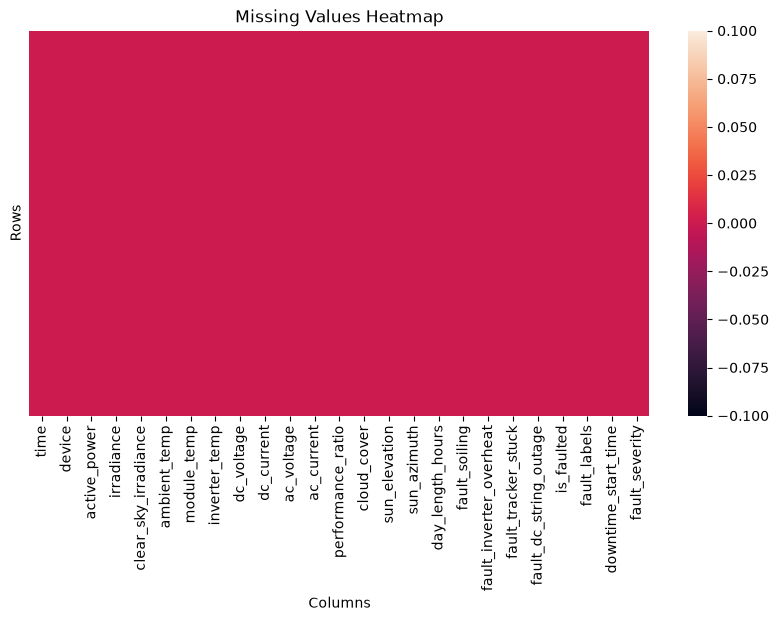

In [84]:
plt.figure(figsize=(10,5))
plt.title("Missing Values Heatmap")
sns.heatmap(df.isnull(),yticklabels=False)
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()

Target analysis

In [85]:
df["is_faulted"].value_counts()

is_faulted
0    418320
1    107280
Name: count, dtype: int64

In [86]:
df['fault_severity'].value_counts()

fault_severity
none      418320
high      100308
low         3548
medium      3424
Name: count, dtype: int64

In [87]:
df["is_faulted"].value_counts(normalize=True) * 100

is_faulted
0    79.589041
1    20.410959
Name: proportion, dtype: float64

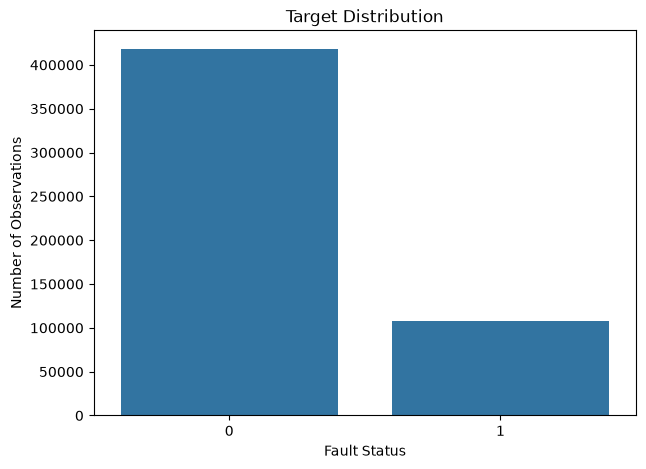

In [88]:
plt.figure(figsize=(7, 5))
plt.title("Target Distribution")
sns.countplot(data=df,x="is_faulted")
plt.xlabel("Fault Status")
plt.ylabel("Number of Observations")

plt.show()

## Device profile

In [89]:
device_fault_ratio = df.groupby("device")["is_faulted"].mean() * 100
device_fault_ratio

device
PV000     0.000000
PV001    43.834665
PV002     0.526065
PV003    38.515982
PV004    19.178082
Name: is_faulted, dtype: float64

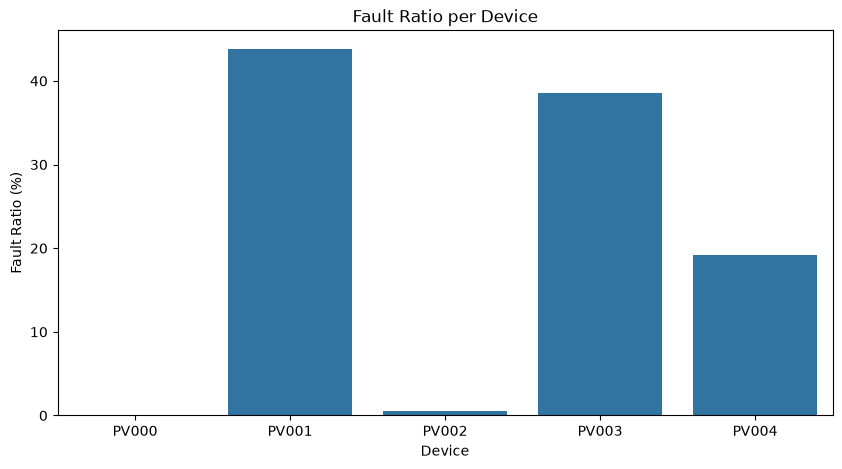

In [90]:
plt.figure(figsize=(10, 5))
plt.title("Fault Ratio per Device")
sns.barplot(x=device_fault_ratio.index, y=device_fault_ratio.values)
plt.xlabel("Device")
plt.ylabel("Fault Ratio (%)")
plt.show()

In [91]:
device_fault_types = pd.crosstab(df["device"], df["fault_labels"])
device_fault_types

fault_labels,dc_string_outage,dc_string_outage|downtime,downtime,healthy,inverter_overheat,soiling,tracker_stuck
device,,,,,,,
PV000,0,0,0,105120,0,0,0
PV001,0,0,0,59041,0,46079,0
PV002,0,0,33,104567,520,0,0
PV003,0,0,168,64632,0,0,40320
PV004,20106,54,0,84960,0,0,0


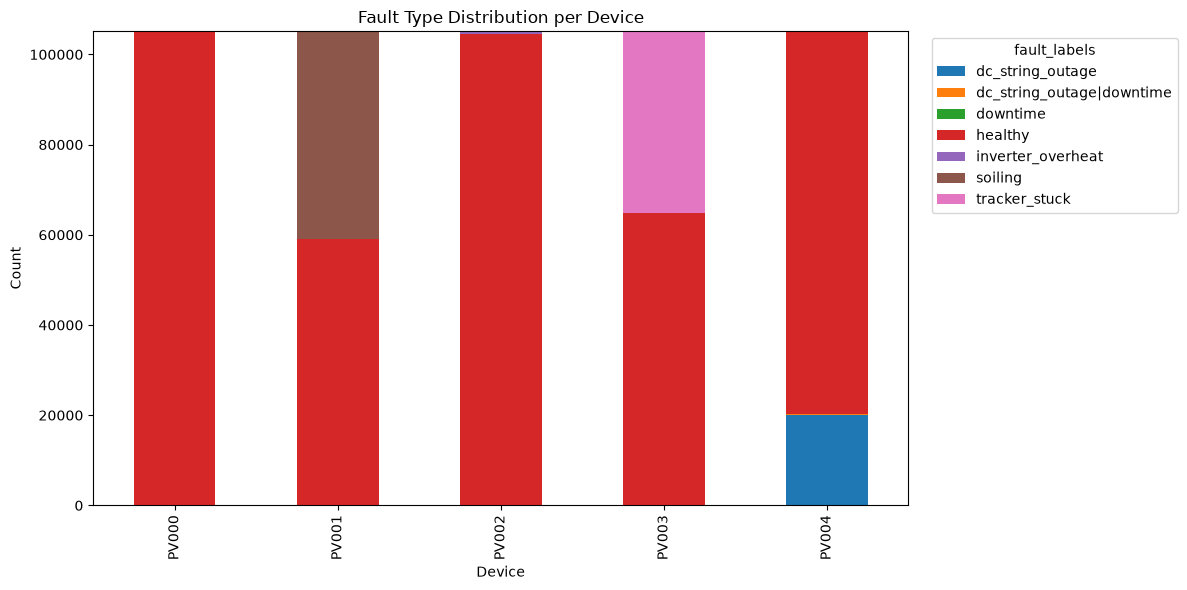

In [92]:
device_fault_types.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)
plt.title("Fault Type Distribution per Device")
plt.xlabel("Device")
plt.ylabel("Count")
plt.legend(title="fault_labels", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [93]:
device_power = df.groupby("device")["active_power"].mean()
device_power

device
PV000     999.171325
PV001     939.780527
PV002    1004.772148
PV003     878.718844
PV004     866.535098
Name: active_power, dtype: float64

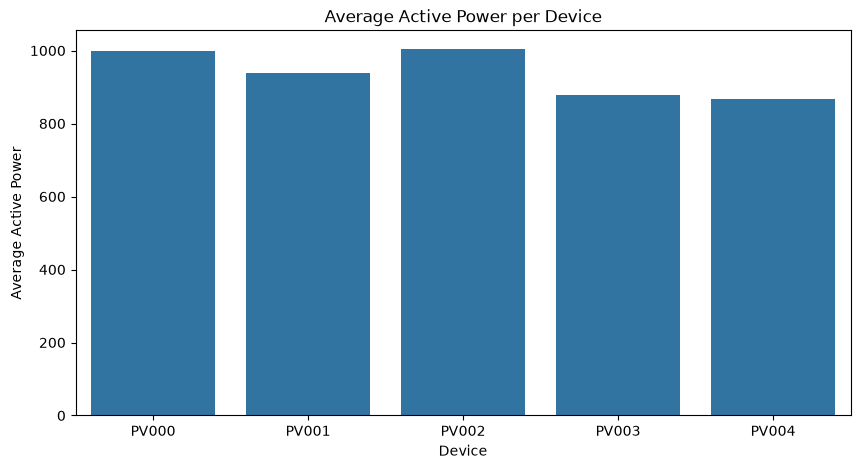

In [94]:
plt.figure(figsize=(10, 5))
plt.title("Average Active Power per Device")
sns.barplot(x=device_power.index, y=device_power.values)
plt.xlabel("Device")
plt.ylabel("Average Active Power")
plt.show()

In [95]:
device_pr = df.groupby("device")["performance_ratio"].mean()
device_pr

device
PV000    0.394768
PV001    0.377038
PV002    0.398142
PV003    0.338823
PV004    0.338832
Name: performance_ratio, dtype: float64

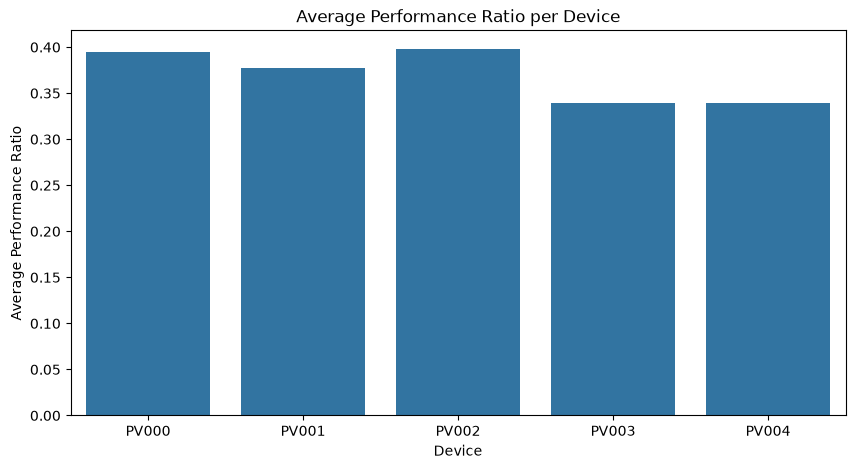

In [96]:
plt.figure(figsize=(10, 5))
plt.title("Average Performance Ratio per Device")
sns.barplot(x=device_pr.index, y=device_pr.values)
plt.xlabel("Device")
plt.ylabel("Average Performance Ratio")
plt.show()

Numerical Features Analysis

In [97]:
df.select_dtypes(include=np.number).columns

Index(['active_power', 'irradiance', 'clear_sky_irradiance', 'ambient_temp',
       'module_temp', 'inverter_temp', 'dc_voltage', 'dc_current',
       'ac_voltage', 'ac_current', 'performance_ratio', 'cloud_cover',
       'sun_elevation', 'sun_azimuth', 'day_length_hours', 'fault_soiling',
       'fault_inverter_overheat', 'fault_tracker_stuck',
       'fault_dc_string_outage', 'is_faulted'],
      dtype='str')

In [98]:
numeric_features = (
    df.select_dtypes(include=np.number)
      .columns.drop([
          'is_faulted',
          'fault_soiling',
          'fault_inverter_overheat',
          'fault_tracker_stuck',
          'fault_dc_string_outage'
      ])
)

numeric_features

Index(['active_power', 'irradiance', 'clear_sky_irradiance', 'ambient_temp',
       'module_temp', 'inverter_temp', 'dc_voltage', 'dc_current',
       'ac_voltage', 'ac_current', 'performance_ratio', 'cloud_cover',
       'sun_elevation', 'sun_azimuth', 'day_length_hours'],
      dtype='str')

In [99]:
df[numeric_features].describe()

,active_power,irradiance,clear_sky_irradiance,ambient_temp,module_temp,inverter_temp,dc_voltage,dc_current,ac_voltage,ac_current,performance_ratio,cloud_cover,sun_elevation,sun_azimuth,day_length_hours
count,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000
mean,937.795588,229.056011,308.992016,17.971951,25.090230,28.688898,404.690521,1.237591,198.856996,1.441851,0.369521,0.345216,0.288488,179.999155,12.039205
std,1201.651000,295.152747,392.665318,8.657496,15.225925,19.479762,406.559276,1.590191,200.003891,1.836076,0.383538,0.173170,38.598312,100.104030,1.622983
min,0.000000,0.000000,0.000000,-1.220000,-2.380000,-1.760000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-78.420000,0.000000,9.650000
25%,0.000000,0.000000,0.000000,11.020000,12.760000,12.810000,0.000000,0.000000,0.000000,0.000000,0.000000,0.217000,-31.210000,89.630000,10.470000
50%,0.000000,0.000000,9.520000,18.010000,23.250000,24.040000,0.000000,0.000000,0.000000,0.000000,0.000000,0.341000,0.230000,179.995000,12.070000
75%,1894.182500,462.870000,628.172500,24.970000,34.750000,41.820000,813.550000,2.479000,399.990000,2.924000,0.753400,0.469000,31.580000,270.350000,13.610000
max,4400.000000,1188.630000,1219.760000,37.120000,70.090000,92.540000,835.840000,5.718000,408.610000,6.435000,1.020000,0.967000,78.450000,359.990000,14.360000


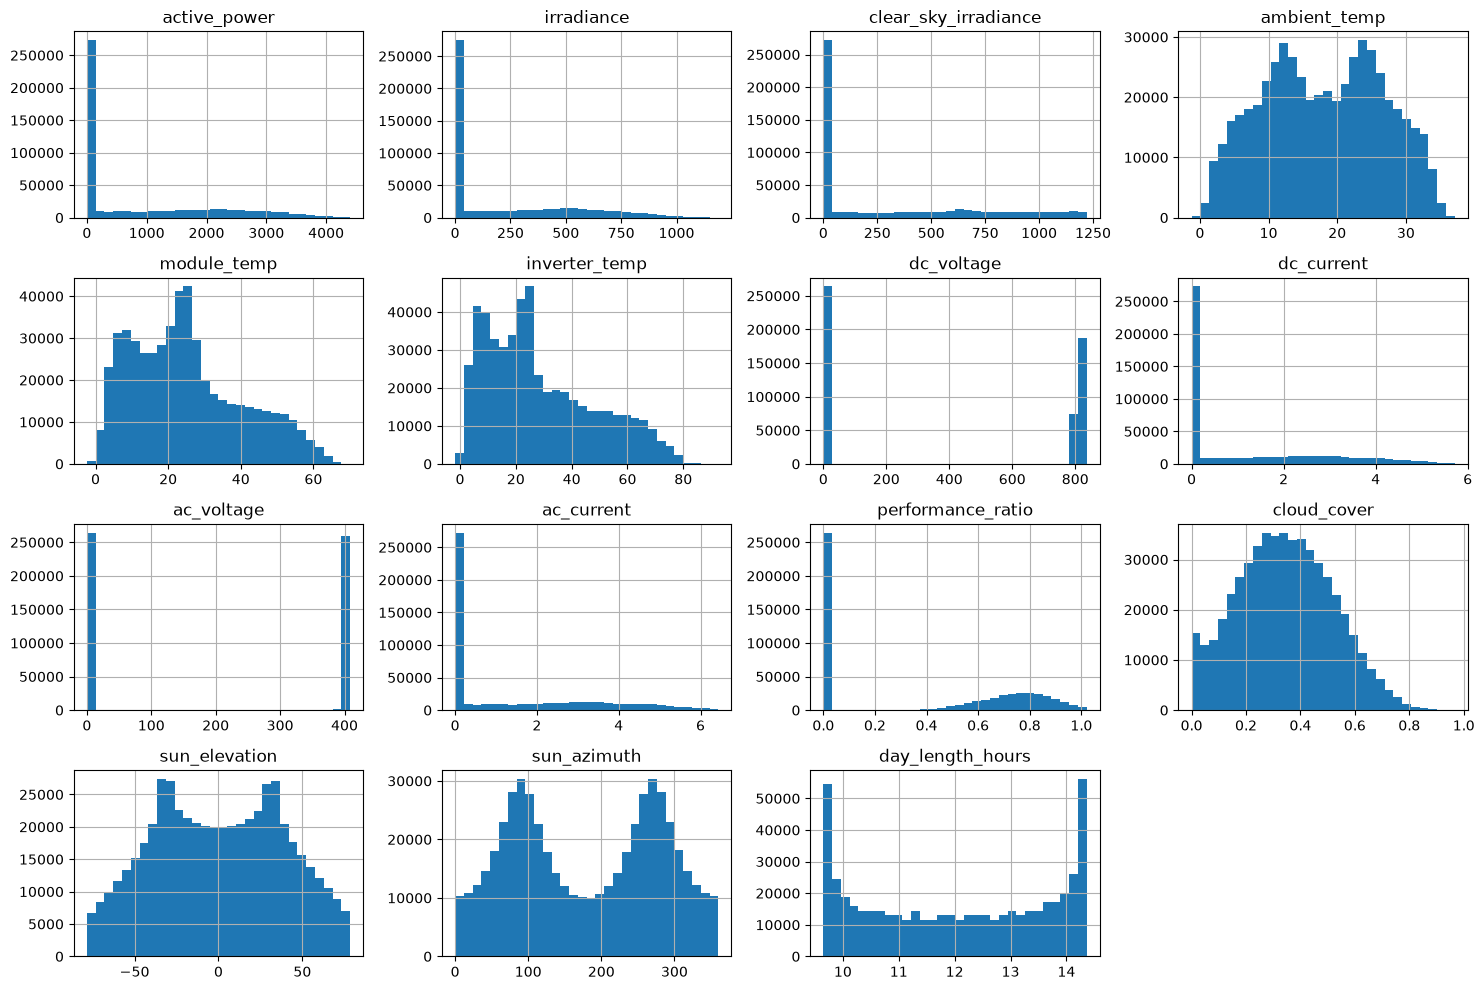

In [100]:
df[numeric_features].hist(
    bins=30,
    figsize=(15, 10)
)

plt.tight_layout()
plt.show()

In [101]:
skewness = df[numeric_features].skew().sort_values(ascending=False)

print(skewness)

irradiance              0.969780
dc_current              0.956697
active_power            0.943011
ac_current              0.917314
clear_sky_irradiance    0.893757
inverter_temp           0.679952
module_temp             0.551877
performance_ratio       0.180151
cloud_cover             0.146748
ac_voltage              0.011592
dc_voltage              0.009765
sun_elevation           0.001773
sun_azimuth            -0.000002
ambient_temp           -0.012573
day_length_hours       -0.034151
dtype: float64


See the Outliers

In [102]:
continuous_features = [
    col for col in numeric_features
    if df[col].nunique() > 2
]

continuous_features

['active_power',
 'irradiance',
 'clear_sky_irradiance',
 'ambient_temp',
 'module_temp',
 'inverter_temp',
 'dc_voltage',
 'dc_current',
 'ac_voltage',
 'ac_current',
 'performance_ratio',
 'cloud_cover',
 'sun_elevation',
 'sun_azimuth',
 'day_length_hours']

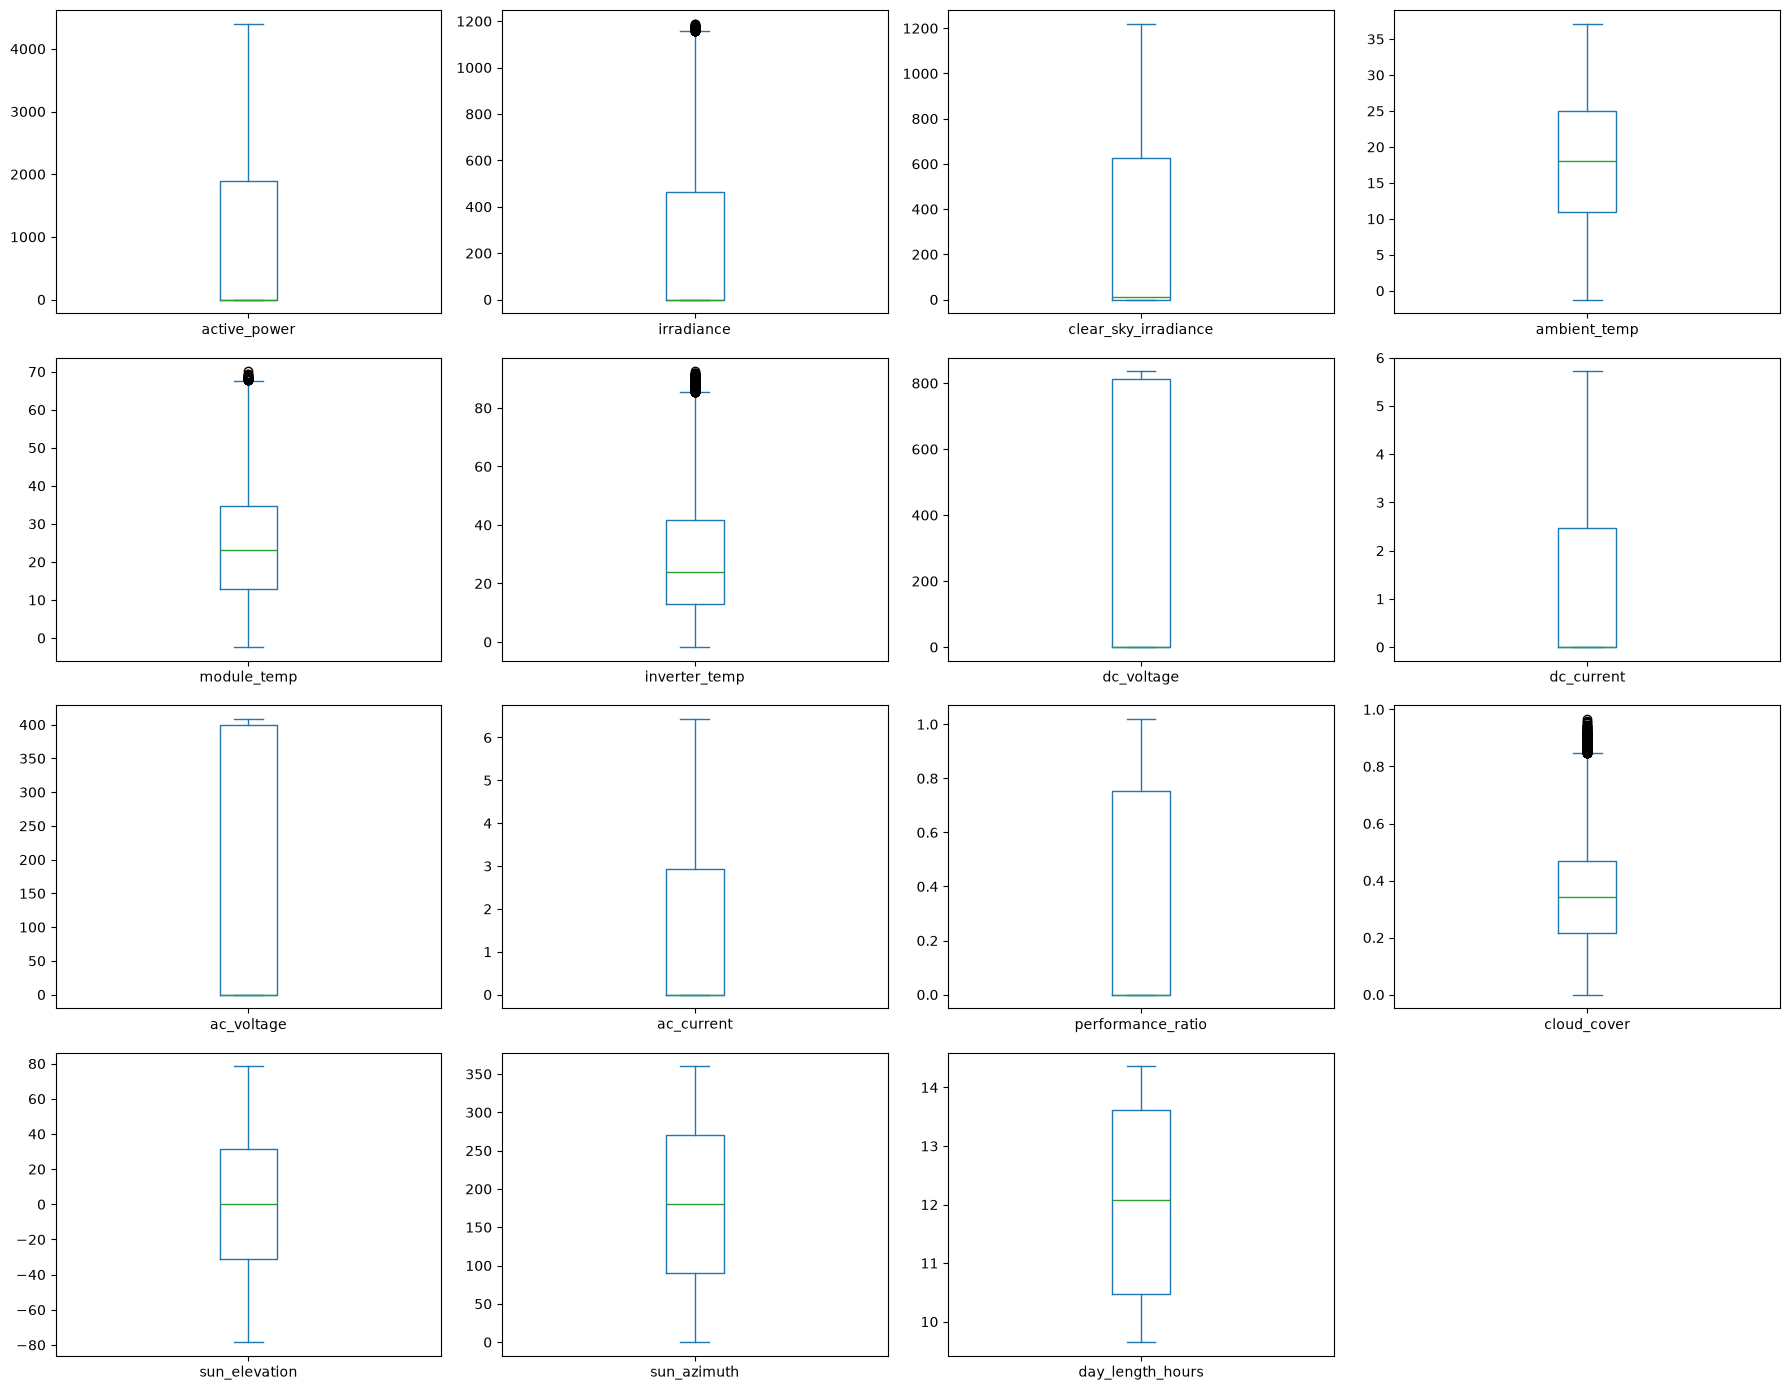

In [103]:
df[continuous_features].plot(
    kind="box",
    subplots=True,
    layout=(4, 4),
    figsize=(18, 14)
)

plt.tight_layout()
plt.show()

Explore Outliers

In [104]:
def check_outliers(data, col, symmetric=True):
   
    plt.figure(figsize=(14, 5))
    sns.boxplot(x=data[col])
    plt.title(f"Boxplot of {col}", fontsize=18)
    plt.xlabel(col, fontsize=14)
    plt.tight_layout()
    plt.show()

    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    if symmetric:
        mask = (data[col] < lower_bound) | (data[col] > upper_bound)
    else:
        mask = data[col] > upper_bound
    outliers = data[col][mask]

    print(f"--- {col} ---")
    print("Q1:", Q1, "| Q3:", Q3, "| IQR:", IQR)
    print("Lower bound:", lower_bound, "| Upper bound:", upper_bound)
    print("Number of outliers:", len(outliers))
    if len(outliers) > 0:
        print("Min outlier:", outliers.min(), "| Max outlier:", outliers.max())
    print()

    return {"lower_bound": lower_bound, "upper_bound": upper_bound, "n_outliers": len(outliers)}

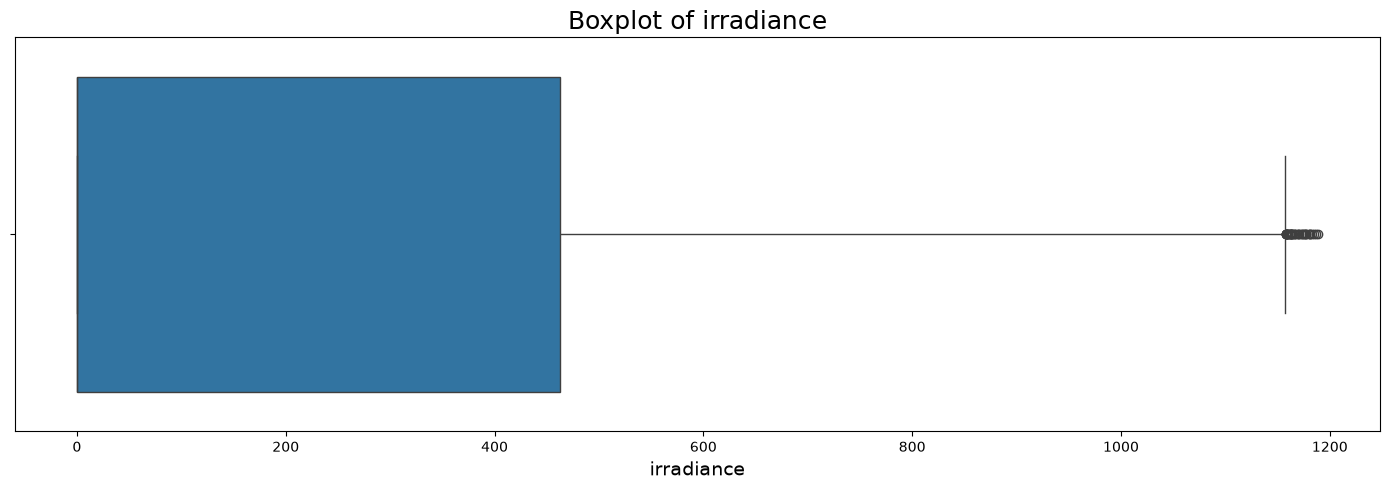

--- irradiance ---
Q1: 0.0 | Q3: 462.87 | IQR: 462.87
Lower bound: -694.3050000000001 | Upper bound: 1157.1750000000002
Number of outliers: 38
Min outlier: 1157.61 | Max outlier: 1188.63



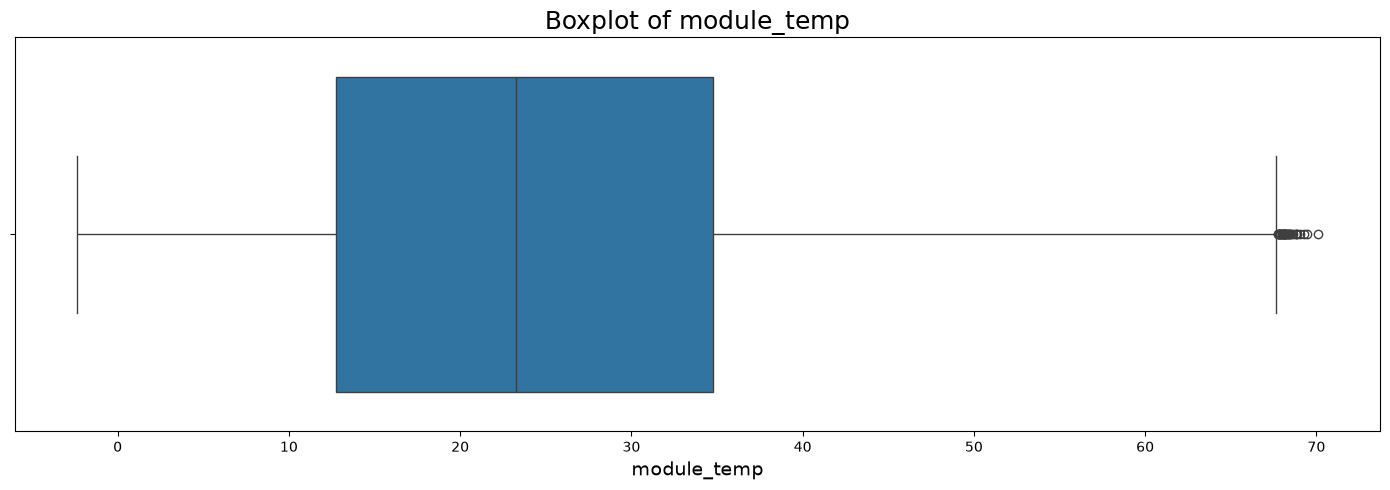

--- module_temp ---
Q1: 12.76 | Q3: 34.75 | IQR: 21.990000000000002
Lower bound: -20.225 | Upper bound: 67.735
Number of outliers: 34
Min outlier: 67.74 | Max outlier: 70.09



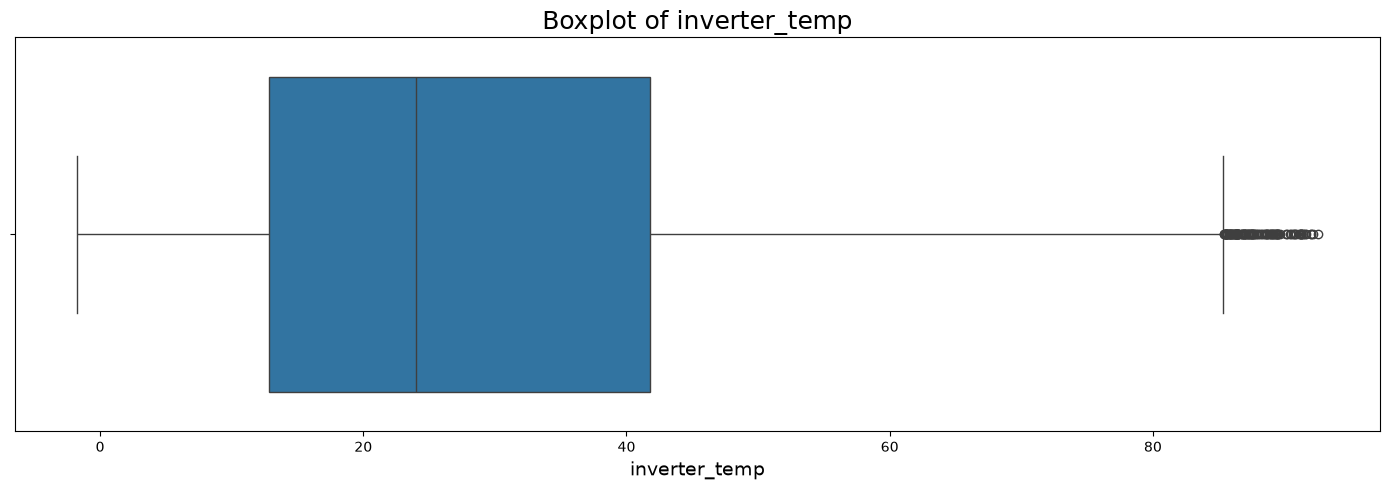

--- inverter_temp ---
Q1: 12.81 | Q3: 41.82 | IQR: 29.009999999999998
Lower bound: -30.705 | Upper bound: 85.33500000000001
Number of outliers: 118
Min outlier: 85.39 | Max outlier: 92.54



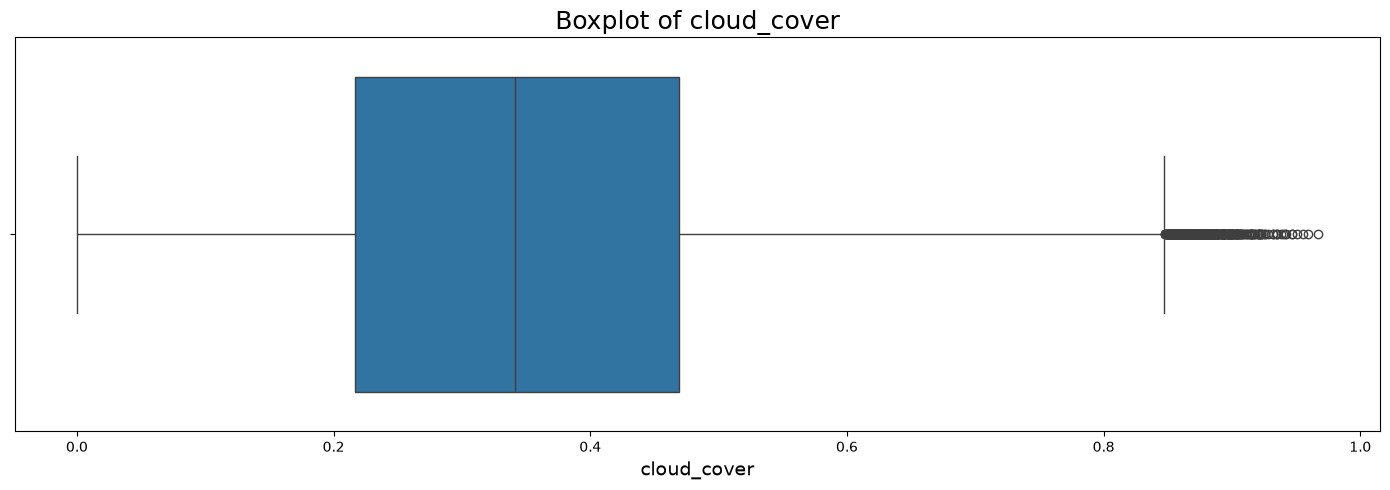

--- cloud_cover ---
Q1: 0.217 | Q3: 0.469 | IQR: 0.252
Lower bound: -0.161 | Upper bound: 0.847
Number of outliers: 432
Min outlier: 0.848 | Max outlier: 0.967



{'irradiance': {'lower_bound': -694.3050000000001,
  'upper_bound': 1157.1750000000002,
  'n_outliers': 38},
 'module_temp': {'lower_bound': -20.225,
  'upper_bound': 67.735,
  'n_outliers': 34},
 'inverter_temp': {'lower_bound': -30.705,
  'upper_bound': 85.33500000000001,
  'n_outliers': 118},
 'cloud_cover': {'lower_bound': -0.161,
  'upper_bound': 0.847,
  'n_outliers': 432}}

In [105]:
outlier_summary = {}
outlier_summary["irradiance"] = check_outliers(df, "irradiance", symmetric=False)
outlier_summary["module_temp"] = check_outliers(df, "module_temp")
outlier_summary["inverter_temp"] = check_outliers(df, "inverter_temp")
outlier_summary["cloud_cover"] = check_outliers(df, "cloud_cover")

outlier_summary

Correlation Analysis

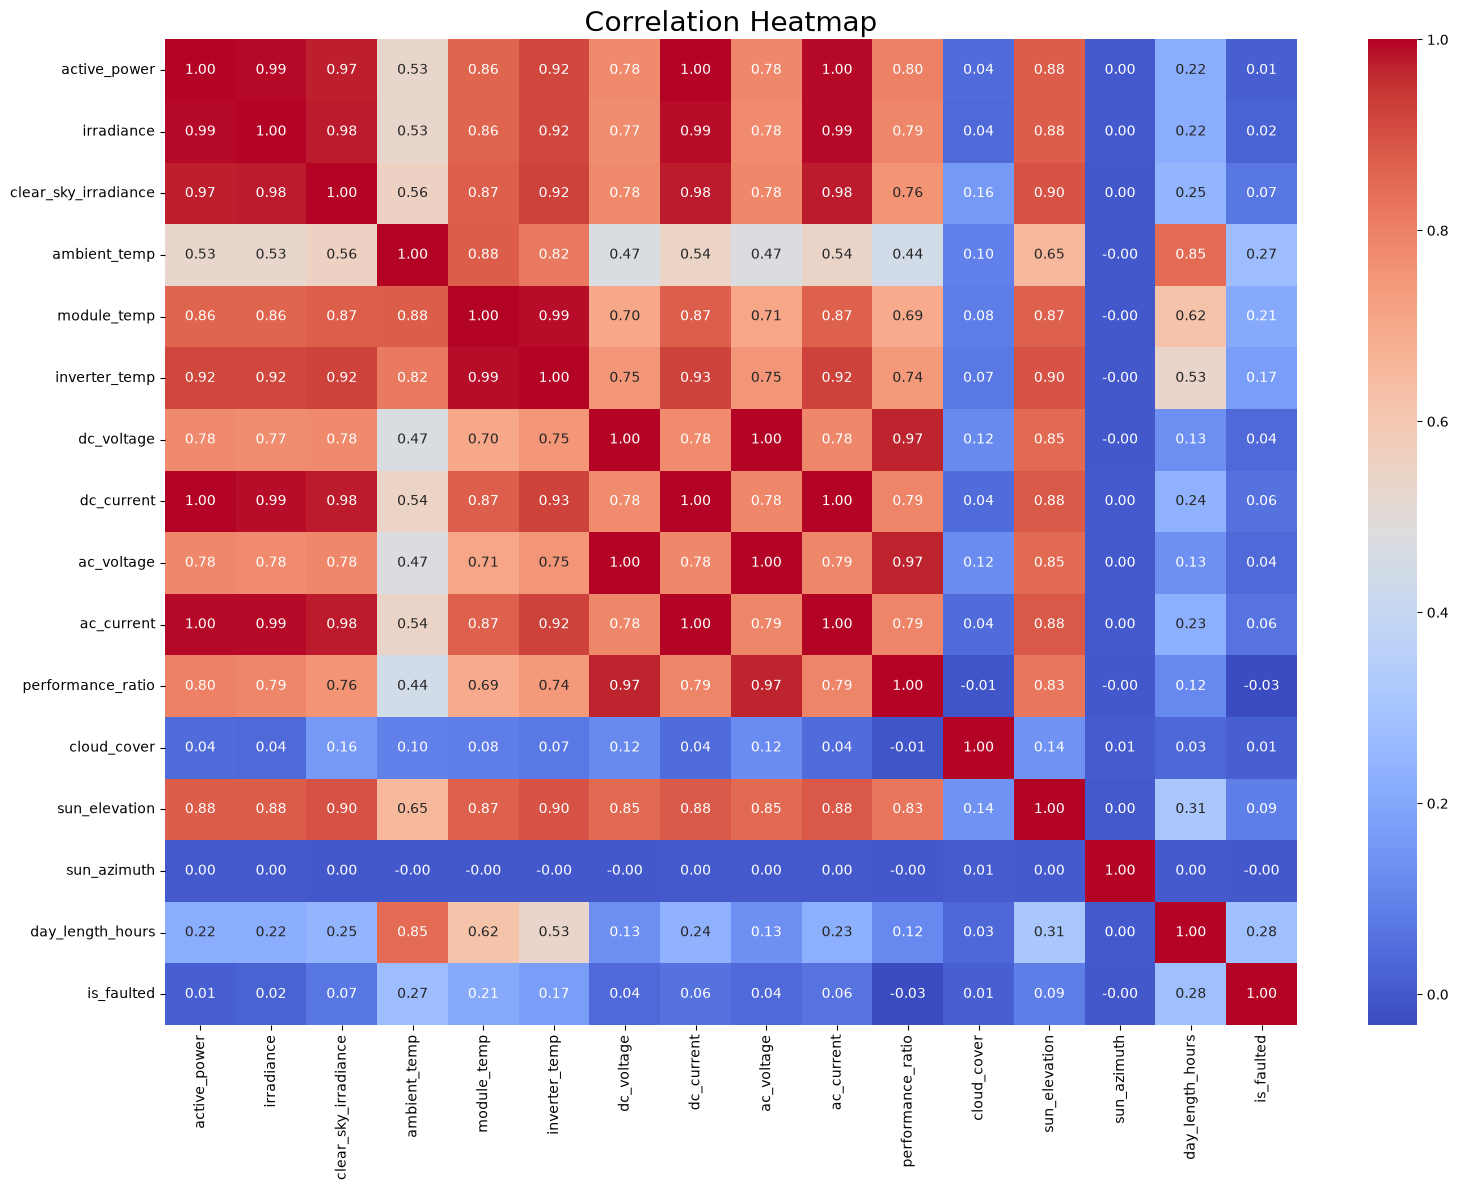

In [106]:
plt.figure(figsize=(16, 12))
plt.title("Correlation Heatmap", fontsize=20)
sns.heatmap(
    df[continuous_features + ["is_faulted"]].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.tight_layout()
plt.show()

## The relation between Features and 1st model 

In [107]:
corr_with_target = (
    df[numeric_features]
    .corr()["active_power"]
    .sort_values(ascending=False)
)

corr_with_target

active_power            1.000000
dc_current              0.996508
ac_current              0.995253
irradiance              0.994563
clear_sky_irradiance    0.974894
inverter_temp           0.916888
sun_elevation           0.878378
module_temp             0.862354
performance_ratio       0.800865
ac_voltage              0.784887
dc_voltage              0.778332
ambient_temp            0.529966
day_length_hours        0.219329
cloud_cover             0.042891
sun_azimuth             0.000108
Name: active_power, dtype: float64

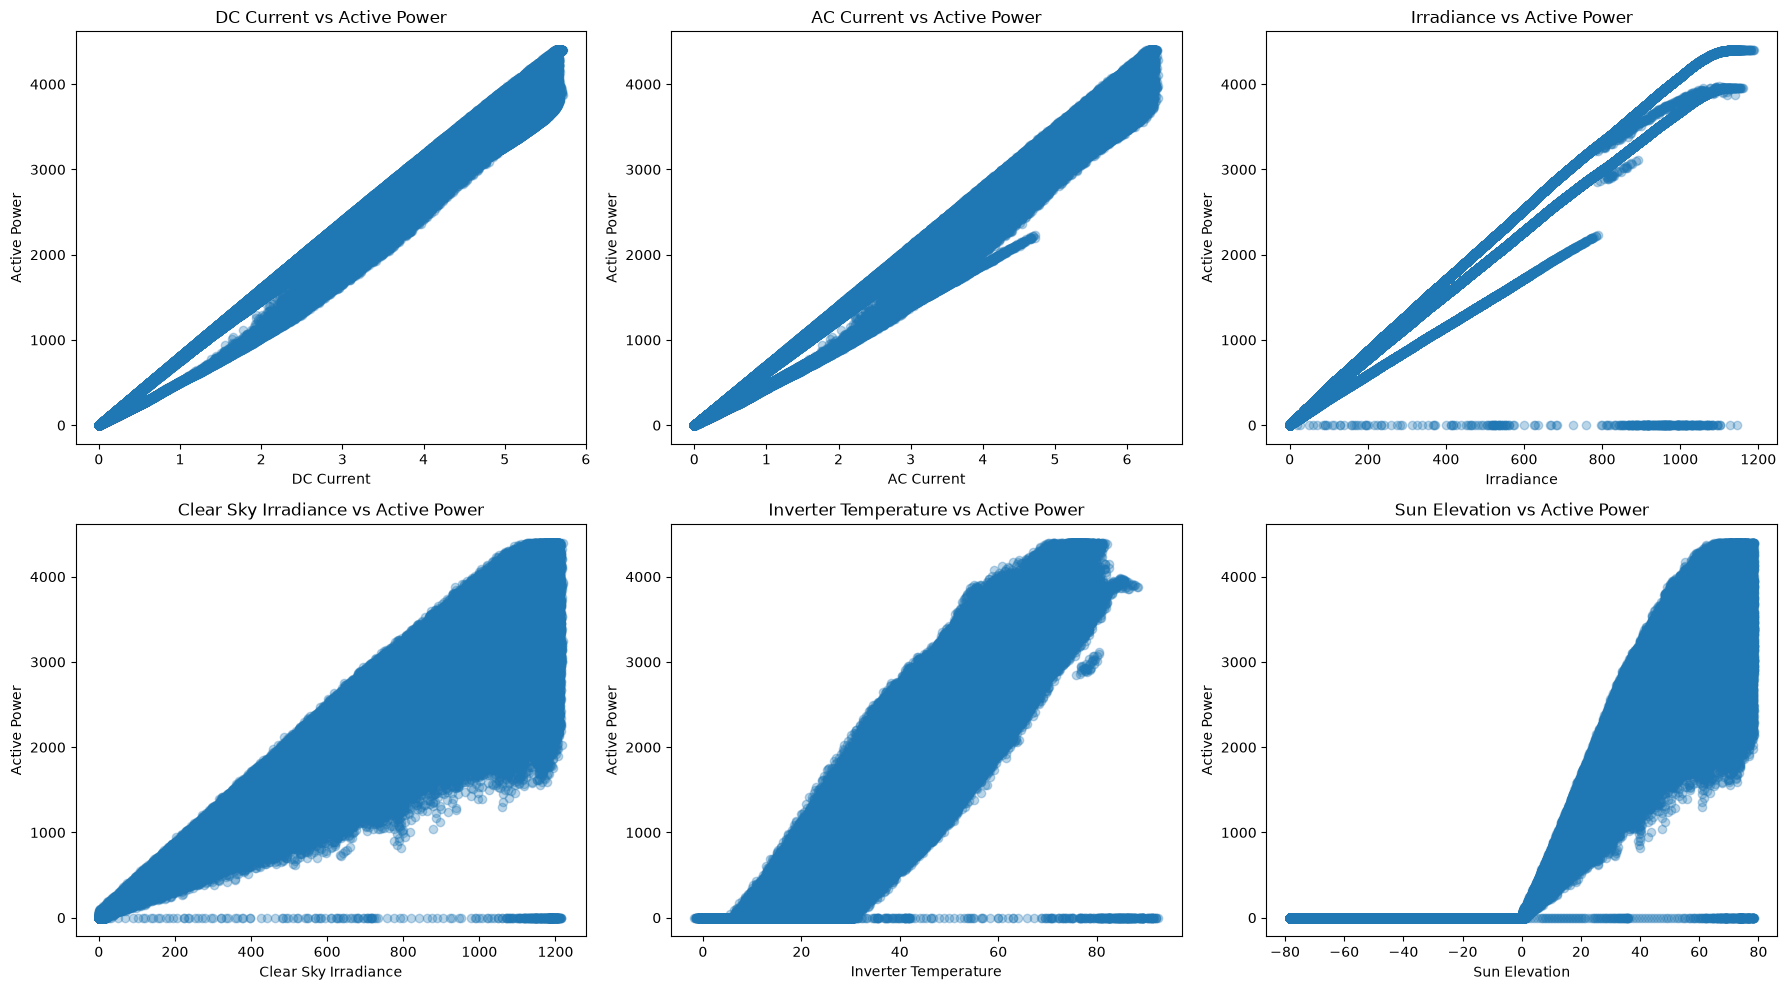

In [108]:
plt.figure(figsize=(18, 10))

plt.subplot(2, 3, 1)
plt.scatter(df["dc_current"], df["active_power"], alpha=0.3)
plt.title("DC Current vs Active Power")
plt.xlabel("DC Current")
plt.ylabel("Active Power")

plt.subplot(2, 3, 2)
plt.scatter(df["ac_current"], df["active_power"], alpha=0.3)
plt.title("AC Current vs Active Power")
plt.xlabel("AC Current")
plt.ylabel("Active Power")

plt.subplot(2, 3, 3)
plt.scatter(df["irradiance"], df["active_power"], alpha=0.3)
plt.title("Irradiance vs Active Power")
plt.xlabel("Irradiance")
plt.ylabel("Active Power")

plt.subplot(2, 3, 4)
plt.scatter(df["clear_sky_irradiance"], df["active_power"], alpha=0.3)
plt.title("Clear Sky Irradiance vs Active Power")
plt.xlabel("Clear Sky Irradiance")
plt.ylabel("Active Power")

plt.subplot(2, 3, 5)
plt.scatter(df["inverter_temp"], df["active_power"], alpha=0.3)
plt.title("Inverter Temperature vs Active Power")
plt.xlabel("Inverter Temperature")
plt.ylabel("Active Power")

plt.subplot(2, 3, 6)
plt.scatter(df["sun_elevation"], df["active_power"], alpha=0.3)
plt.title("Sun Elevation vs Active Power")
plt.xlabel("Sun Elevation")
plt.ylabel("Active Power")

plt.tight_layout()
plt.show()

## The relation between Features and 2nd model 

In [109]:
corr_with_fault = (
    df[numeric_features.tolist() + ["is_faulted"]]
    .corr()["is_faulted"]
    .sort_values(ascending=False)
)

corr_with_fault

is_faulted              1.000000
day_length_hours        0.280335
ambient_temp            0.270431
module_temp             0.207753
inverter_temp           0.172375
sun_elevation           0.090996
clear_sky_irradiance    0.071160
ac_current              0.061819
dc_current              0.058629
ac_voltage              0.037542
dc_voltage              0.037229
irradiance              0.021569
active_power            0.014230
cloud_cover             0.012817
sun_azimuth            -0.000166
performance_ratio      -0.032199
Name: is_faulted, dtype: float64

In [110]:
fault_features = [
    'day_length_hours',
    'ambient_temp',
    'module_temp',
    'inverter_temp',
    'sun_elevation',
    'clear_sky_irradiance',
    'ac_current',
    'dc_current'
]

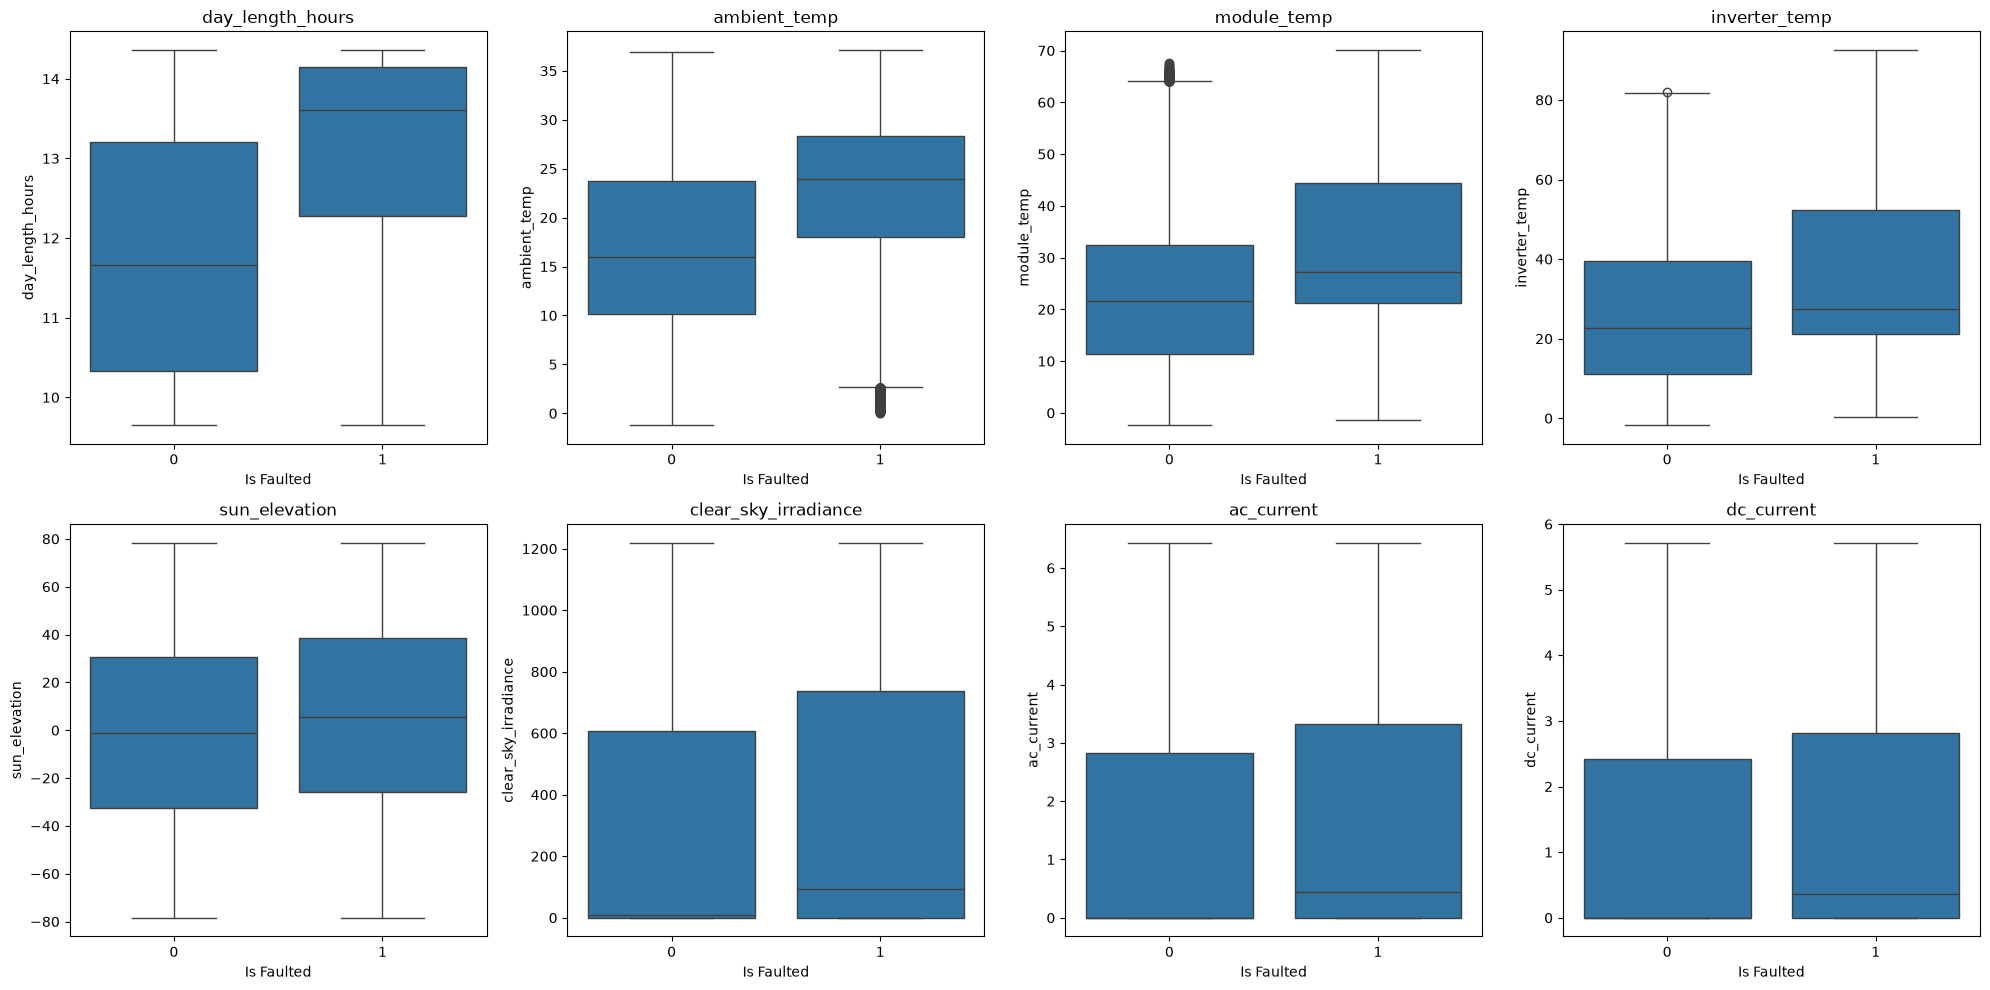

In [111]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for ax, feature in zip(axes.flat, fault_features):

    sns.boxplot(
        data=df,
        x='is_faulted',
        y=feature,
        ax=ax
    )

    ax.set_title(feature)
    ax.set_xlabel("Is Faulted")
    ax.set_ylabel(feature)

plt.tight_layout()
plt.show()

## The relation between Features and third model 

# fault soiling

In [112]:
corr_soiling = (
    df.corr(numeric_only=True)["fault_soiling"]
    .sort_values(ascending=False)
)

corr_soiling

fault_soiling              1.000000
is_faulted                 0.612129
ambient_temp               0.280297
day_length_hours           0.277711
module_temp                0.218301
inverter_temp              0.174089
sun_elevation              0.086339
dc_current                 0.072877
clear_sky_irradiance       0.067277
ac_current                 0.064070
active_power               0.048231
irradiance                 0.039491
ac_voltage                 0.038009
dc_voltage                 0.036110
performance_ratio          0.027165
cloud_cover                0.013553
sun_azimuth                0.000271
fault_inverter_overheat   -0.009755
fault_dc_string_outage    -0.061910
fault_tracker_stuck       -0.089354
Name: fault_soiling, dtype: float64

# fault_inverter_overheat

In [113]:
corr_overheat = (
    df.corr(numeric_only=True)["fault_inverter_overheat"]
    .sort_values(ascending=False)
)

corr_overheat

fault_inverter_overheat    1.000000
inverter_temp              0.084582
module_temp                0.077865
irradiance                 0.076599
clear_sky_irradiance       0.068741
is_faulted                 0.062142
ambient_temp               0.061035
sun_elevation              0.058411
day_length_hours           0.039763
dc_current                 0.038697
ac_current                 0.036337
active_power               0.035895
dc_voltage                 0.030298
performance_ratio          0.015821
ac_voltage                 0.009390
sun_azimuth                0.004086
cloud_cover               -0.001139
fault_dc_string_outage    -0.006285
fault_tracker_stuck       -0.009071
fault_soiling             -0.009755
Name: fault_inverter_overheat, dtype: float64

# fault_tracker_stuck

In [114]:
corr_tracker = (
    df.corr(numeric_only=True)["fault_tracker_stuck"]
    .sort_values(ascending=False)
)

corr_tracker

fault_tracker_stuck        1.000000
is_faulted                 0.569192
day_length_hours           0.298933
ambient_temp               0.225598
module_temp                0.182786
inverter_temp              0.148316
sun_elevation              0.092997
clear_sky_irradiance       0.072390
dc_current                 0.072052
ac_current                 0.066036
dc_voltage                 0.041497
ac_voltage                 0.040767
active_power               0.029615
irradiance                 0.022238
cloud_cover                0.008660
sun_azimuth                0.000315
fault_inverter_overheat   -0.009071
performance_ratio         -0.022384
fault_dc_string_outage    -0.057567
fault_soiling             -0.089354
Name: fault_tracker_stuck, dtype: float64

# fault_dc_string_outage

In [115]:
corr_string = (
    df.corr(numeric_only=True)["fault_dc_string_outage"]
    .sort_values(ascending=False)
)

corr_string

fault_dc_string_outage     1.000000
is_faulted                 0.394371
sun_azimuth               -0.000125
cloud_cover               -0.004089
fault_inverter_overheat   -0.006285
ac_voltage                -0.033234
dc_voltage                -0.037840
irradiance                -0.057028
fault_tracker_stuck       -0.057567
ac_current                -0.060504
clear_sky_irradiance      -0.061887
fault_soiling             -0.061910
sun_elevation             -0.075229
performance_ratio         -0.077230
active_power              -0.086520
dc_current                -0.088906
inverter_temp             -0.115494
module_temp               -0.153239
ambient_temp              -0.169968
day_length_hours          -0.243058
Name: fault_dc_string_outage, dtype: float64

## Feature Engineering

In [116]:
df['dc_power'] = (df['dc_voltage'] * df['dc_current']) 

df['ac_power'] = (df['ac_voltage'] * df['ac_current']) 

df['inverter_efficiency'] = np.where(df['dc_power'] > 0, df['ac_power'] / df['dc_power'], 0.0)

df['inverter_efficiency'] = df['inverter_efficiency'].clip(lower=0.0, upper=1.0)

## convert str to datetime and sorting 

In [117]:
df['downtime_start_time'] = pd.to_datetime(df['downtime_start_time'])
df['time'] = pd.to_datetime(df['time'])
df = df.sort_values('time')

In [118]:
df['hour'] = df['time'].dt.hour
df['month'] = df['time'].dt.month
df['day_of_week'] = df['time'].dt.dayofweek
df['is_daylight'] = df['hour'].between(6, 18).astype(int)
df = df.set_index('time')

## Time gaps check

In [119]:
time_series = df.index.to_series()
df["time_diff_min"] = time_series.groupby(df["device"]).diff().dt.total_seconds() / 60.0

In [120]:
expected_gap_min = df["time_diff_min"].mode()[0]

gaps = df[df["time_diff_min"] > expected_gap_min]
gaps_per_device = gaps.groupby("device").size()

print("Expected gap between readings (minutes):", expected_gap_min)
print("Total gaps found:", len(gaps))
gaps_per_device

Expected gap between readings (minutes): 5.0
Total gaps found: 0


Series([], dtype: int64)

In [121]:
df = df.drop(columns=["time_diff_min"])

## calculate downtime in min

In [122]:
df['downtime_duration_min'] = (df.index - df['downtime_start_time']).dt.total_seconds() / 60.0
df['downtime_duration_min'] = df['downtime_duration_min'].fillna(0).clip(lower=0)

df = df.drop(columns=['downtime_start_time'])

In [123]:
df.head()

,device,active_power,irradiance,clear_sky_irradiance,ambient_temp,module_temp,inverter_temp,dc_voltage,dc_current,ac_voltage,ac_current,performance_ratio,cloud_cover,sun_elevation,sun_azimuth,day_length_hours,fault_soiling,fault_inverter_overheat,fault_tracker_stuck,fault_dc_string_outage,is_faulted,fault_labels,fault_severity,dc_power,ac_power,inverter_efficiency,hour,month,day_of_week,is_daylight,downtime_duration_min
time,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2025-01-01,PV000,0.0,0.0,4.88,2.20,1.90,1.99,0.0,0.0,0.0,0.0,0.0,0.424,-78.04,356.77,9.69,0,0,0,0,0,healthy,none,0.0,0.0,0.0,0,1,2,0,0.0
2025-01-01,PV001,0.0,0.0,1.29,2.43,3.65,3.02,0.0,0.0,0.0,0.0,0.0,0.386,-78.04,356.77,9.69,0,0,0,0,0,healthy,none,0.0,0.0,0.0,0,1,2,0,0.0
2025-01-01,PV002,0.0,0.0,1.08,2.08,3.60,2.81,0.0,0.0,0.0,0.0,0.0,0.373,-78.04,356.77,9.69,0,0,0,0,0,healthy,none,0.0,0.0,0.0,0,1,2,0,0.0
2025-01-01,PV003,0.0,0.0,0.00,2.07,2.97,2.50,0.0,0.0,0.0,0.0,0.0,0.397,-78.04,356.77,9.69,0,0,0,0,0,healthy,none,0.0,0.0,0.0,0,1,2,0,0.0
2025-01-01,PV004,0.0,0.0,0.15,2.06,0.81,1.41,0.0,0.0,0.0,0.0,0.0,0.376,-78.04,356.77,9.69,0,0,0,0,0,healthy,none,0.0,0.0,0.0,0,1,2,0,0.0


## Encoding

In [124]:
df['fault_severity'].value_counts()

fault_severity
none      418320
high      100308
low         3548
medium      3424
Name: count, dtype: int64

In [125]:
df['fault_severity'] = df['fault_severity'].map({'none':0,'low':1,'medium':2,'high':3})

## Check imbalance

### Is_faulted

is_faulted
0    418320
1    107280
Name: count, dtype: int64

is_faulted
0    79.589041
1    20.410959
Name: proportion, dtype: float64


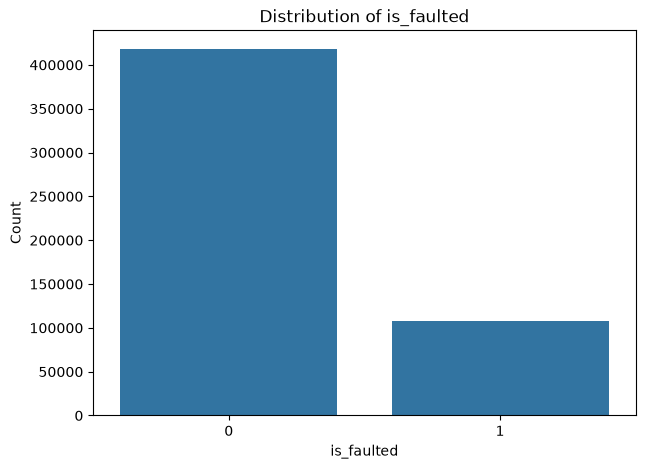

In [126]:
print(df["is_faulted"].value_counts())
print()
print(df["is_faulted"].value_counts(normalize=True) * 100)

plt.figure(figsize=(7, 5))
plt.title("Distribution of is_faulted")
sns.countplot(data=df, x="is_faulted")
plt.xlabel("is_faulted")
plt.ylabel("Count")
plt.show()

### fault_labels

fault_labels
healthy                      418320
soiling                       46079
tracker_stuck                 40320
dc_string_outage              20106
inverter_overheat               520
downtime                        201
dc_string_outage|downtime        54
Name: count, dtype: int64

fault_labels
healthy                      79.589041
soiling                       8.766933
tracker_stuck                 7.671233
dc_string_outage              3.825342
inverter_overheat             0.098935
downtime                      0.038242
dc_string_outage|downtime     0.010274
Name: proportion, dtype: float64


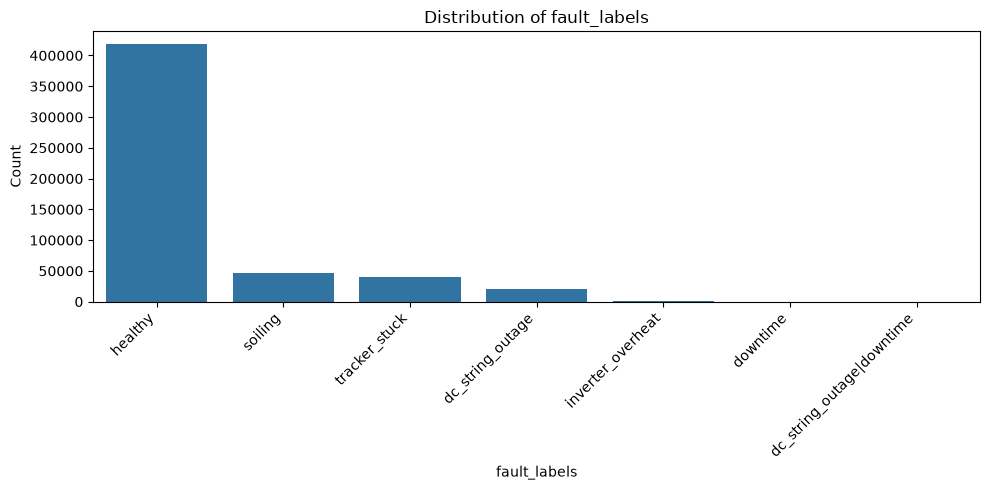

In [127]:
print(df["fault_labels"].value_counts())
print()
print(df["fault_labels"].value_counts(normalize=True) * 100)

plt.figure(figsize=(10, 5))
plt.title("Distribution of fault_labels")
sns.countplot(data=df, x="fault_labels", order=df["fault_labels"].value_counts().index)
plt.xlabel("fault_labels")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### fault_severity

fault_severity
0    418320
3    100308
1      3548
2      3424
Name: count, dtype: int64

fault_severity
0    79.589041
3    19.084475
1     0.675038
2     0.651446
Name: proportion, dtype: float64


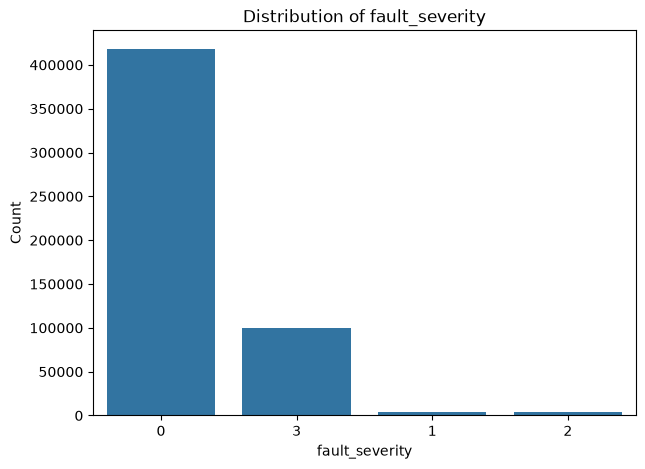

In [128]:
print(df["fault_severity"].value_counts())
print()
print(df["fault_severity"].value_counts(normalize=True) * 100)

plt.figure(figsize=(7, 5))
plt.title("Distribution of fault_severity")
sns.countplot(data=df, x="fault_severity", order=df["fault_severity"].value_counts().index)
plt.xlabel("fault_severity")
plt.ylabel("Count")
plt.show()

## Train / Test Split — General Strategy


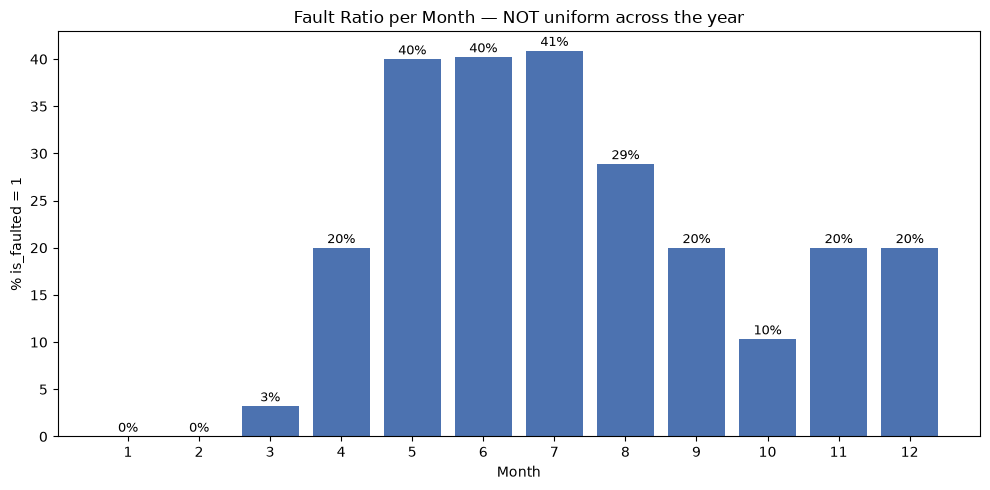

In [129]:
monthly_fault_ratio = df.groupby(df.index.month)["is_faulted"].mean() * 100

plt.figure(figsize=(10, 5))
bars = plt.bar(monthly_fault_ratio.index, monthly_fault_ratio.values, color="#4C72B0")
plt.title("Fault Ratio per Month — NOT uniform across the year")
plt.xlabel("Month")
plt.ylabel("% is_faulted = 1")
plt.xticks(range(1, 13))
for b in bars:
    plt.text(b.get_x() + b.get_width()/2, b.get_height()+0.5, f"{b.get_height():.0f}%", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

### Step 2: Solution — Blocked Time Split per (device × week)


In [130]:
def time_block_split(group, train_frac=0.8):
    """Chronological 80/20 split within one group (device, week).
    First `train_frac` of the rows (already sorted by time) go to train,
    the last remaining rows go to test -> train always precedes test.
    """
    n = len(group)
    cut = int(np.floor(n * train_frac))
    return group.iloc[:cut], group.iloc[cut:]

df["week"] = df.index.isocalendar().week

train_parts, test_parts = [], []
for _, g in df.groupby(["device", "week"], sort=False):
    tr, te = time_block_split(g)
    train_parts.append(tr)
    test_parts.append(te)

train_df = pd.concat(train_parts).sort_index()
test_df = pd.concat(test_parts).sort_index()

df = df.drop(columns=["week"])
train_df = train_df.drop(columns=["week"])
test_df = test_df.drop(columns=["week"])

print("train_df:", train_df.shape)
print("test_df :", test_df.shape)
print(f"train is_faulted ratio: {train_df['is_faulted'].mean()*100:.2f}%")
print(f"test  is_faulted ratio: {test_df['is_faulted'].mean()*100:.2f}%")

train_df: (420275, 31)
test_df : (105325, 31)
train is_faulted ratio: 20.30%
test  is_faulted ratio: 20.85%


### Step 3: Visual Confirmation the Split Is Balanced


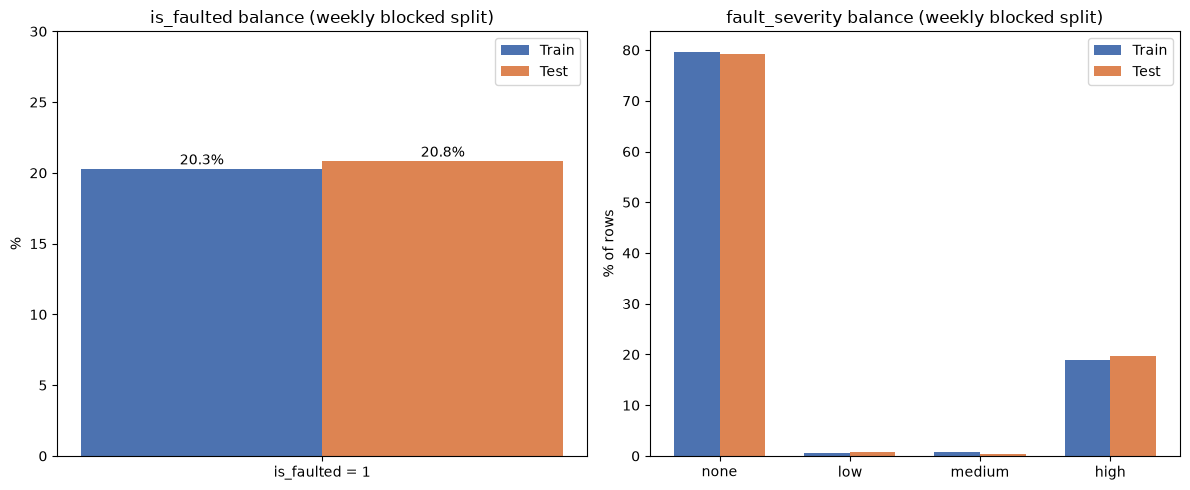

In [131]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
w = 0.35

ax = axes[0]
v_train = train_df["is_faulted"].mean() * 100
v_test = test_df["is_faulted"].mean() * 100
ax.bar(0 - w/2, v_train, w, label="Train", color="#4C72B0")
ax.bar(0 + w/2, v_test, w, label="Test", color="#DD8452")
ax.set_xticks([0]); ax.set_xticklabels(["is_faulted = 1"])
ax.set_ylabel("%"); ax.set_ylim(0, 30)
ax.set_title("is_faulted balance (weekly blocked split)")
ax.text(0 - w/2, v_train + 0.3, f"{v_train:.1f}%", ha="center")
ax.text(0 + w/2, v_test + 0.3, f"{v_test:.1f}%", ha="center")
ax.legend()

order = [0, 1, 2, 3]
labels = ["none", "low", "medium", "high"]
st = train_df["fault_severity"].value_counts(normalize=True).reindex(order) * 100
se = test_df["fault_severity"].value_counts(normalize=True).reindex(order) * 100
ax2 = axes[1]
xs = np.arange(4)
ax2.bar(xs - w/2, st.values, w, label="Train", color="#4C72B0")
ax2.bar(xs + w/2, se.values, w, label="Test", color="#DD8452")
ax2.set_xticks(xs); ax2.set_xticklabels(labels)
ax2.set_ylabel("% of rows")
ax2.set_title("fault_severity balance (weekly blocked split)")
ax2.legend()

plt.tight_layout()
plt.show()

## Model 1: Predict Active Power (`active_power`) — Regression

### Columns to Drop (Data Leakage) for This Model


In [132]:
leakage_cols_general = [
    "device",
    "is_faulted", "fault_labels", "fault_severity",
    "fault_soiling", "fault_inverter_overheat", "fault_tracker_stuck", "fault_dc_string_outage",
    "downtime_duration_min",
]

model1_extra_leakage = [
    "active_power",
    "ac_power", "dc_power",
    "ac_voltage", "ac_current", "dc_voltage", "dc_current",
    "inverter_efficiency",
    "performance_ratio",
]

model1_drop_cols = leakage_cols_general + model1_extra_leakage
model1_features = [c for c in df.columns if c not in model1_drop_cols]

print("Number of features to use in Model 1:", len(model1_features))
model1_features

Number of features to use in Model 1: 13


['irradiance',
 'clear_sky_irradiance',
 'ambient_temp',
 'module_temp',
 'inverter_temp',
 'cloud_cover',
 'sun_elevation',
 'sun_azimuth',
 'day_length_hours',
 'hour',
 'month',
 'day_of_week',
 'is_daylight']

In [133]:
X_train_m1 = train_df[model1_features]
y_train_m1 = train_df["active_power"]

X_test_m1 = test_df[model1_features]
y_test_m1 = test_df["active_power"]

print("X_train_m1:", X_train_m1.shape)
print("X_test_m1 :", X_test_m1.shape)
print("y_train_m1:", y_train_m1.shape)
print("y_test_m1 :", y_test_m1.shape)

X_train_m1.head()

X_train_m1: (420275, 13)
X_test_m1 : (105325, 13)
y_train_m1: (420275,)
y_test_m1 : (105325,)


,irradiance,clear_sky_irradiance,ambient_temp,module_temp,inverter_temp,cloud_cover,sun_elevation,sun_azimuth,day_length_hours,hour,month,day_of_week,is_daylight
time,,,,,,,,,,,,,
2025-01-01,0.0,4.88,2.20,1.90,1.99,0.424,-78.04,356.77,9.69,0,1,2,0
2025-01-01,0.0,1.08,2.08,3.60,2.81,0.373,-78.04,356.77,9.69,0,1,2,0
2025-01-01,0.0,0.00,2.07,2.97,2.50,0.397,-78.04,356.77,9.69,0,1,2,0
2025-01-01,0.0,0.15,2.06,0.81,1.41,0.376,-78.04,356.77,9.69,0,1,2,0
2025-01-01,0.0,1.29,2.43,3.65,3.02,0.386,-78.04,356.77,9.69,0,1,2,0


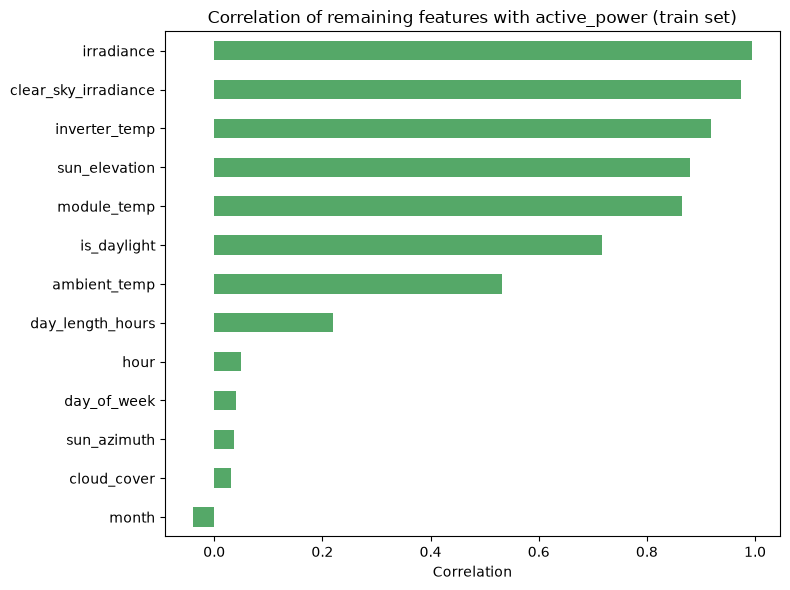

irradiance              0.994415
clear_sky_irradiance    0.974088
inverter_temp           0.918127
sun_elevation           0.880375
module_temp             0.864346
is_daylight             0.717756
ambient_temp            0.531805
day_length_hours        0.219292
hour                    0.049248
day_of_week             0.039657
sun_azimuth             0.036458
cloud_cover             0.032002
month                  -0.039310
dtype: float64

In [134]:
corr_with_target = X_train_m1.select_dtypes(include=np.number).corrwith(y_train_m1).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
corr_with_target.plot(kind="barh", color="#55A868")
plt.title("Correlation of remaining features with active_power (train set)")
plt.xlabel("Correlation")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

corr_with_target

### الموديل الثاني: هل الجهاز فيه عطل؟

هنا بنبني موديل تصنيف ثنائي (Binary Classification) بيحدد هل الجهاز شغال طبيعي (Healthy) ولا فيه عطل (Fault). المشكلة هنا فيها عدم توازن بين الفئتين، فبنحسب class weights عشان نديّ اهتمام أكبر للحالات القليلة (العطل).

## Model 2: Is the Device Faulted? (`is_faulted`) — Binary Classification

### Columns to Drop (Data Leakage) for This Model

### Key Difference from Model 1


In [135]:
model2_drop_cols = leakage_cols_general
model2_features = [c for c in df.columns if c not in model2_drop_cols]

print("Number of features to use in Model 2:", len(model2_features))
model2_features

Number of features to use in Model 2: 22


['active_power',
 'irradiance',
 'clear_sky_irradiance',
 'ambient_temp',
 'module_temp',
 'inverter_temp',
 'dc_voltage',
 'dc_current',
 'ac_voltage',
 'ac_current',
 'performance_ratio',
 'cloud_cover',
 'sun_elevation',
 'sun_azimuth',
 'day_length_hours',
 'dc_power',
 'ac_power',
 'inverter_efficiency',
 'hour',
 'month',
 'day_of_week',
 'is_daylight']

In [136]:
X_train_m2 = train_df[model2_features]
y_train_m2 = train_df["is_faulted"]

X_test_m2 = test_df[model2_features]
y_test_m2 = test_df["is_faulted"]

print("X_train_m2:", X_train_m2.shape)
print("X_test_m2 :", X_test_m2.shape)
print("y_train_m2:", y_train_m2.shape)
print("y_test_m2 :", y_test_m2.shape)

X_train_m2.head()

X_train_m2: (420275, 22)
X_test_m2 : (105325, 22)
y_train_m2: (420275,)
y_test_m2 : (105325,)


,active_power,irradiance,clear_sky_irradiance,ambient_temp,module_temp,inverter_temp,dc_voltage,dc_current,ac_voltage,ac_current,performance_ratio,cloud_cover,sun_elevation,sun_azimuth,day_length_hours,dc_power,ac_power,inverter_efficiency,hour,month,day_of_week,is_daylight
time,,,,,,,,,,,,,,,,,,,,,,
2025-01-01,0.0,0.0,4.88,2.20,1.90,1.99,0.0,0.0,0.0,0.0,0.0,0.424,-78.04,356.77,9.69,0.0,0.0,0.0,0,1,2,0
2025-01-01,0.0,0.0,1.08,2.08,3.60,2.81,0.0,0.0,0.0,0.0,0.0,0.373,-78.04,356.77,9.69,0.0,0.0,0.0,0,1,2,0
2025-01-01,0.0,0.0,0.00,2.07,2.97,2.50,0.0,0.0,0.0,0.0,0.0,0.397,-78.04,356.77,9.69,0.0,0.0,0.0,0,1,2,0
2025-01-01,0.0,0.0,0.15,2.06,0.81,1.41,0.0,0.0,0.0,0.0,0.0,0.376,-78.04,356.77,9.69,0.0,0.0,0.0,0,1,2,0
2025-01-01,0.0,0.0,1.29,2.43,3.65,3.02,0.0,0.0,0.0,0.0,0.0,0.386,-78.04,356.77,9.69,0.0,0.0,0.0,0,1,2,0


### الموديل الثالث: نوع العطل

هنا المشكلة تصنيف متعدد الفئات (Multi-class) لأن فيه أكتر من نوع عطل ممكن يحصل، والموديل بيحدد نوع العطل المحدد اللي حصل بالظبط.

## Model 3: Fault Type (`fault_labels`) — Multi-class Classification

#### Columns to Drop


In [137]:
model3_drop_cols = leakage_cols_general
model3_features = [c for c in df.columns if c not in model3_drop_cols]

print("Number of features to use in Model 3:", len(model3_features))

Number of features to use in Model 3: 22


In [138]:
X_train_m3 = train_df[model3_features]
y_train_m3 = train_df["fault_labels"]

X_test_m3 = test_df[model3_features]
y_test_m3 = test_df["fault_labels"]

excluded_label_m3 = "dc_string_outage|downtime"
train_mask_m3 = y_train_m3 != excluded_label_m3
test_mask_m3 = y_test_m3 != excluded_label_m3

X_train_m3 = X_train_m3[train_mask_m3]
y_train_m3 = y_train_m3[train_mask_m3]
X_test_m3 = X_test_m3[test_mask_m3]
y_test_m3 = y_test_m3[test_mask_m3]

print("X_train_m3:", X_train_m3.shape)
print("X_test_m3 :", X_test_m3.shape)
print("y_train_m3:", y_train_m3.shape)
print("y_test_m3 :", y_test_m3.shape)

X_train_m3.head()

X_train_m3: (420245, 22)
X_test_m3 : (105301, 22)
y_train_m3: (420245,)
y_test_m3 : (105301,)


,active_power,irradiance,clear_sky_irradiance,ambient_temp,module_temp,inverter_temp,dc_voltage,dc_current,ac_voltage,ac_current,performance_ratio,cloud_cover,sun_elevation,sun_azimuth,day_length_hours,dc_power,ac_power,inverter_efficiency,hour,month,day_of_week,is_daylight
time,,,,,,,,,,,,,,,,,,,,,,
2025-01-01,0.0,0.0,4.88,2.20,1.90,1.99,0.0,0.0,0.0,0.0,0.0,0.424,-78.04,356.77,9.69,0.0,0.0,0.0,0,1,2,0
2025-01-01,0.0,0.0,1.08,2.08,3.60,2.81,0.0,0.0,0.0,0.0,0.0,0.373,-78.04,356.77,9.69,0.0,0.0,0.0,0,1,2,0
2025-01-01,0.0,0.0,0.00,2.07,2.97,2.50,0.0,0.0,0.0,0.0,0.0,0.397,-78.04,356.77,9.69,0.0,0.0,0.0,0,1,2,0
2025-01-01,0.0,0.0,0.15,2.06,0.81,1.41,0.0,0.0,0.0,0.0,0.0,0.376,-78.04,356.77,9.69,0.0,0.0,0.0,0,1,2,0
2025-01-01,0.0,0.0,1.29,2.43,3.65,3.02,0.0,0.0,0.0,0.0,0.0,0.386,-78.04,356.77,9.69,0.0,0.0,0.0,0,1,2,0


### Visual Confirmation: Distribution of Fault Types (`fault_labels`) Between Train and Test


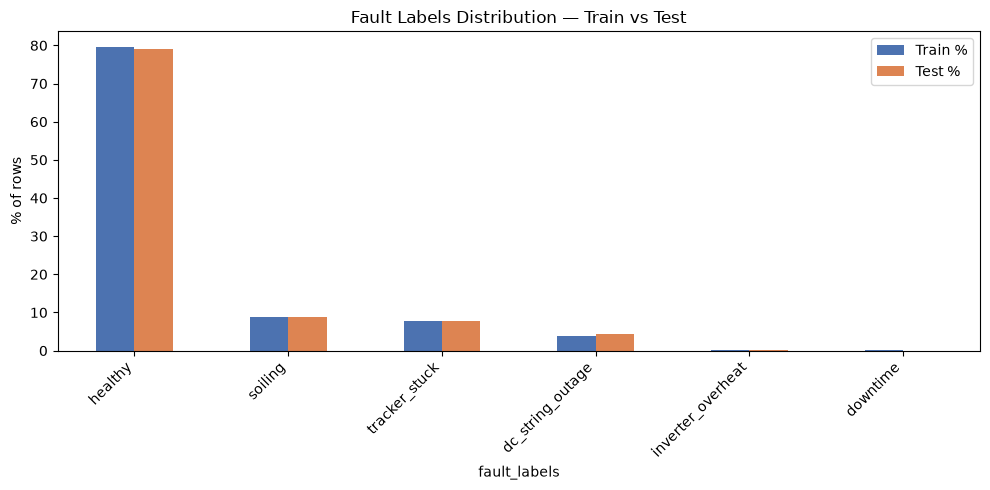

,Train %,Test %
fault_labels,,
healthy,79.704458,79.169239
soiling,8.753703,8.824228
tracker_stuck,7.671715,7.673241
dc_string_outage,3.719021,4.251622
inverter_overheat,0.106842,0.067426
downtime,0.044260,0.014245


In [139]:
train_counts_lbl = y_train_m3.value_counts(normalize=True) * 100
test_counts_lbl = y_test_m3.value_counts(normalize=True) * 100

compare_labels_df = pd.DataFrame({"Train %": train_counts_lbl, "Test %": test_counts_lbl}).fillna(0)
compare_labels_df = compare_labels_df.sort_values("Train %", ascending=False)

compare_labels_df.plot(kind="bar", figsize=(10, 5), color=["#4C72B0", "#DD8452"])
plt.title("Fault Labels Distribution — Train vs Test")
plt.xlabel("fault_labels")
plt.ylabel("% of rows")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

compare_labels_df

### الموديل الرابع: شدة العطل

هنا كمان تصنيف متعدد الفئات، لكن المرة دي الموديل بيحدد مستوى خطورة العطل (لا يوجد / بسيط / متوسط / عالي).

## Model 4: Fault Severity (`fault_severity`) — Ordinal / Multi-class Classification

#### Columns to Drop


In [140]:
model4_drop_cols = leakage_cols_general
model4_features = [c for c in df.columns if c not in model4_drop_cols]

print("Number of features to use in Model 4:", len(model4_features))

Number of features to use in Model 4: 22


In [141]:
X_train_m4 = train_df[model4_features]
y_train_m4 = train_df["fault_severity"]

X_test_m4 = test_df[model4_features]
y_test_m4 = test_df["fault_severity"]

print("X_train_m4:", X_train_m4.shape)
print("X_test_m4 :", X_test_m4.shape)
print("y_train_m4:", y_train_m4.shape)
print("y_test_m4 :", y_test_m4.shape)

X_train_m4.head()

X_train_m4: (420275, 22)
X_test_m4 : (105325, 22)
y_train_m4: (420275,)
y_test_m4 : (105325,)


,active_power,irradiance,clear_sky_irradiance,ambient_temp,module_temp,inverter_temp,dc_voltage,dc_current,ac_voltage,ac_current,performance_ratio,cloud_cover,sun_elevation,sun_azimuth,day_length_hours,dc_power,ac_power,inverter_efficiency,hour,month,day_of_week,is_daylight
time,,,,,,,,,,,,,,,,,,,,,,
2025-01-01,0.0,0.0,4.88,2.20,1.90,1.99,0.0,0.0,0.0,0.0,0.0,0.424,-78.04,356.77,9.69,0.0,0.0,0.0,0,1,2,0
2025-01-01,0.0,0.0,1.08,2.08,3.60,2.81,0.0,0.0,0.0,0.0,0.0,0.373,-78.04,356.77,9.69,0.0,0.0,0.0,0,1,2,0
2025-01-01,0.0,0.0,0.00,2.07,2.97,2.50,0.0,0.0,0.0,0.0,0.0,0.397,-78.04,356.77,9.69,0.0,0.0,0.0,0,1,2,0
2025-01-01,0.0,0.0,0.15,2.06,0.81,1.41,0.0,0.0,0.0,0.0,0.0,0.376,-78.04,356.77,9.69,0.0,0.0,0.0,0,1,2,0
2025-01-01,0.0,0.0,1.29,2.43,3.65,3.02,0.0,0.0,0.0,0.0,0.0,0.386,-78.04,356.77,9.69,0.0,0.0,0.0,0,1,2,0


### Visual Confirmation: Distribution of Fault Severity (`fault_severity`) Between Train and Test


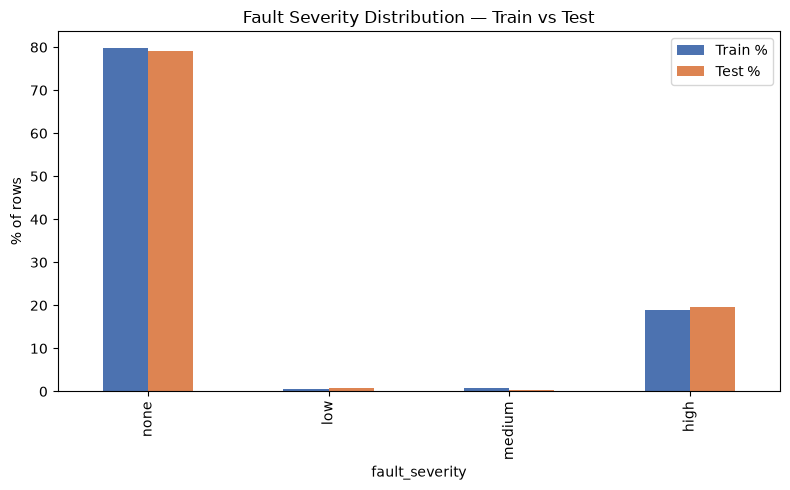

,Train %,Test %
fault_severity,,
none,79.698769,79.151199
low,0.644102,0.798481
medium,0.717149,0.389271
high,18.939980,19.661049


In [142]:
sev_labels = {0: "none", 1: "low", 2: "medium", 3: "high"}

train_counts_sev = y_train_m4.value_counts(normalize=True).reindex([0, 1, 2, 3]) * 100
test_counts_sev = y_test_m4.value_counts(normalize=True).reindex([0, 1, 2, 3]) * 100

compare_sev_df = pd.DataFrame({"Train %": train_counts_sev, "Test %": test_counts_sev})
compare_sev_df.index = compare_sev_df.index.map(sev_labels)

compare_sev_df.plot(kind="bar", figsize=(8, 5), color=["#4C72B0", "#DD8452"])
plt.title("Fault Severity Distribution — Train vs Test")
plt.xlabel("fault_severity")
plt.ylabel("% of rows")
plt.tight_layout()
plt.show()

compare_sev_df

##### Summary: Everything Ready Before Modeling


---
# Part Two: Actual Modeling

### Why CatBoost and LightGBM Specifically?


### شرح مبسط بالعربي - جزء الموديلينج

في الجزء ده هنبني 4 موديلات:
- **الموديل الأول**: يتوقع كمية الطاقة المنتجة (`active_power`) - مشكلة Regression (توقع رقم).
- **الموديل الثاني**: يحدد هل فيه عطل ولا لأ (`is_faulted`) - تصنيف ثنائي (Healthy / Fault).
- **الموديل الثالث**: يحدد نوع العطل (`fault_labels`) - تصنيف متعدد الفئات.
- **الموديل الرابع**: يحدد شدة العطل (`fault_severity`) - تصنيف متعدد (none / low / medium / high).

كل موديل هندربه بخوارزميتين قويين هما **CatBoost** و **LightGBM**، وبعدين هندمج نتايجهم مع بعض (Ensemble / Blend) عشان نطلع بأحسن أداء ممكن.

In [143]:
from catboost import CatBoostRegressor, CatBoostClassifier
from lightgbm import LGBMRegressor, LGBMClassifier

from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score, roc_curve
)

import optuna
from sklearn.model_selection import train_test_split
optuna.logging.set_verbosity(optuna.logging.WARNING)


### إيه هو Optuna؟

بدل ما نجرب الإعدادات (Hyperparameters زي عمق الشجرة أو معدل التعلم) يدويًا واحدة واحدة، بنستخدم مكتبة **Optuna** اللي بتجرب عدد كبير من الاحتمالات تلقائيًا وتختار أحسن إعدادات بتدي أقل خطأ (أو أعلى F1-Score حسب نوع المشكلة). ده بيوفر وقت وبيدي نتيجة أفضل من التجربة اليدوية.

### Hyperparameter Tuning with Optuna (Model 1 — active_power)

Instead of picking `depth`/`learning_rate` manually, we let Optuna search over the hyperparameter space and pick the combination that minimizes validation RMSE.

In [144]:
X_tr_opt_m1, X_val_opt_m1, y_tr_opt_m1, y_val_opt_m1 = train_test_split(
    X_train_m1, y_train_m1, test_size=0.2, random_state=42
)


In [145]:
def objective_cat_m1(trial):
    params = {
        "iterations": trial.suggest_int("iterations", 300, 800),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "depth": trial.suggest_int("depth", 4, 10),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 10.0, log=True),
        "loss_function": "RMSE",
        "random_state": 42,
        "verbose": False
    }
    model = CatBoostRegressor(**params)
    model.fit(X_tr_opt_m1, y_tr_opt_m1, eval_set=(X_val_opt_m1, y_val_opt_m1),
              early_stopping_rounds=50, verbose=False)
    preds = model.predict(X_val_opt_m1)
    return np.sqrt(mean_squared_error(y_val_opt_m1, preds))

study_cat_m1 = optuna.create_study(direction="minimize", study_name="catboost_m1")
study_cat_m1.optimize(objective_cat_m1, n_trials=25, show_progress_bar=True)

best_params_cat_m1 = study_cat_m1.best_params
print("Best CatBoost (Model 1) params:", best_params_cat_m1)
print("Best validation RMSE:", study_cat_m1.best_value)


  0%|          | 0/25 [00:00<?, ?it/s]

Best CatBoost (Model 1) params: {'iterations': 791, 'learning_rate': 0.29581514908388407, 'depth': 9, 'l2_leaf_reg': 2.011947828256464}
Best validation RMSE: 67.07311830017561


In [146]:

cat_reg_m1 = CatBoostRegressor(
    **best_params_cat_m1,
    loss_function="RMSE",
    random_state=42,
    verbose=False
)

cat_reg_m1.fit(X_train_m1, y_train_m1)

pred_cat_m1 = cat_reg_m1.predict(X_test_m1)


In [147]:
def objective_lgbm_m1(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 300, 800),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 4, 10),
        "num_leaves": trial.suggest_int("num_leaves", 20, 150),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "random_state": 42,
        "verbose": -1
    }
    model = LGBMRegressor(**params)
    model.fit(X_tr_opt_m1, y_tr_opt_m1)
    preds = model.predict(X_val_opt_m1)
    return np.sqrt(mean_squared_error(y_val_opt_m1, preds))

study_lgbm_m1 = optuna.create_study(direction="minimize", study_name="lgbm_m1")
study_lgbm_m1.optimize(objective_lgbm_m1, n_trials=25, show_progress_bar=True)

best_params_lgbm_m1 = study_lgbm_m1.best_params
print("Best LightGBM (Model 1) params:", best_params_lgbm_m1)
print("Best validation RMSE:", study_lgbm_m1.best_value)


  0%|          | 0/25 [00:00<?, ?it/s]

Best LightGBM (Model 1) params: {'n_estimators': 713, 'learning_rate': 0.20406912877340366, 'max_depth': 8, 'num_leaves': 107, 'subsample': 0.611940224728623, 'colsample_bytree': 0.9341975773902326}
Best validation RMSE: 69.80666770431205


In [148]:

lgbm_reg_m1 = LGBMRegressor(
    **best_params_lgbm_m1,
    random_state=42,
    verbose=-1
)

lgbm_reg_m1.fit(X_train_m1, y_train_m1)

pred_lgbm_m1 = lgbm_reg_m1.predict(X_test_m1)


In [149]:

def regression_report(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"--- {model_name} (Model 1: active_power) ---")
    print(f"MAE  : {mae:.3f}")
    print(f"RMSE : {rmse:.3f}")
    print(f"R2   : {r2:.4f}")
    print()

    return {"Model": model_name, "MAE": mae, "RMSE": rmse, "R2": r2}

results_m1 = []
results_m1.append(regression_report(y_test_m1, pred_cat_m1, "CatBoost"))
results_m1.append(regression_report(y_test_m1, pred_lgbm_m1, "LightGBM"))

results_m1_df = pd.DataFrame(results_m1)
results_m1_df

--- CatBoost (Model 1: active_power) ---
MAE  : 16.993
RMSE : 62.203
R2   : 0.9969

--- LightGBM (Model 1: active_power) ---
MAE  : 15.041
RMSE : 65.273
R2   : 0.9966



,Model,MAE,RMSE,R2
0,CatBoost,16.992747,62.202964,0.99694
1,LightGBM,15.041408,65.272511,0.99663


### إيه معنى Ensemble / Blend؟

بعد ما ندرب الموديلين (CatBoost و LightGBM) بنجمع توقعاتهم مع بعض (بناخد المتوسط) عشان نطلع بتوقع أدق من كل موديل لوحده. الفكرة إن كل موديل ممكن يكون كويس في حاجات ومش كويس في حاجات تانية، فلما ندمجهم بنقلل الأخطاء ونحسّن الأداء العام.

### Ensemble: Blending CatBoost + LightGBM (Model 1 — active_power)

In [150]:
pred_blend_m1 = (pred_cat_m1 + pred_lgbm_m1) / 2

best_w, best_rmse = None, np.inf
for w in np.arange(0, 1.05, 0.05):
    pred_w = w * pred_cat_m1 + (1 - w) * pred_lgbm_m1
    rmse = np.sqrt(mean_squared_error(y_test_m1, pred_w))
    if rmse < best_rmse:
        best_rmse, best_w = rmse, w

pred_weighted_m1 = best_w * pred_cat_m1 + (1 - best_w) * pred_lgbm_m1
print(f"Best weight for CatBoost: {best_w:.2f}  |  Weighted Blend RMSE: {best_rmse:.4f}")

results_m1.append(regression_report(y_test_m1, pred_blend_m1, "Blend (Simple Avg)"))
results_m1.append(regression_report(y_test_m1, pred_weighted_m1, "Blend (Weighted)"))

results_m1_df = pd.DataFrame(results_m1)
results_m1_df


Best weight for CatBoost: 0.65  |  Weighted Blend RMSE: 60.4313
--- Blend (Simple Avg) (Model 1: active_power) ---
MAE  : 14.689
RMSE : 60.627
R2   : 0.9971

--- Blend (Weighted) (Model 1: active_power) ---
MAE  : 15.133
RMSE : 60.431
R2   : 0.9971



,Model,MAE,RMSE,R2
0,CatBoost,16.992747,62.202964,0.996940
1,LightGBM,15.041408,65.272511,0.996630
2,Blend (Simple Avg),14.689190,60.626787,0.997093
3,Blend (Weighted),15.133416,60.431331,0.997111


### Visualization 1: Comparing the 3 Metrics Between the Two Models Side by Side


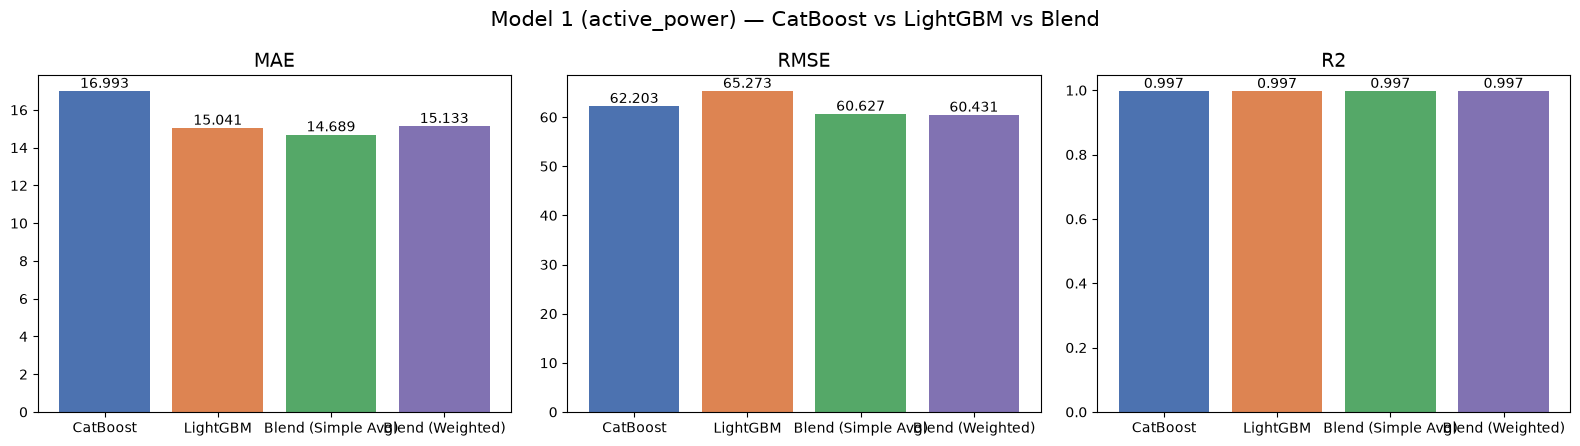

In [151]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
metrics_m1 = ["MAE", "RMSE", "R2"]
colors_m1 = ["#4C72B0", "#DD8452", "#55A868", "#8172B2"]

for ax, metric in zip(axes, metrics_m1):
    bars = ax.bar(results_m1_df["Model"], results_m1_df[metric], color=colors_m1)
    ax.set_title(metric, fontsize=14)
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height(), f"{b.get_height():.3f}",
                 ha="center", va="bottom", fontsize=10)

plt.suptitle("Model 1 (active_power) — CatBoost vs LightGBM vs Blend", fontsize=15)
plt.tight_layout()
plt.show()

### Visualization 4: Feature Importance


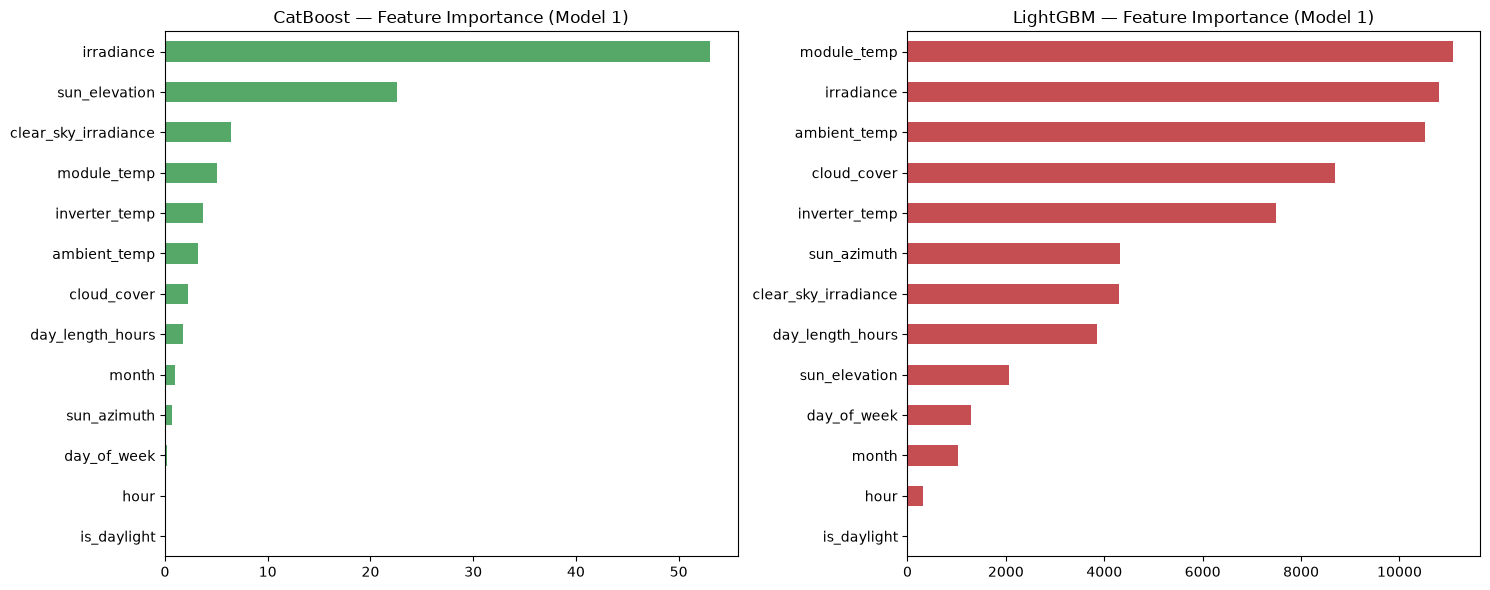

In [152]:
cat_importance_m1 = pd.Series(
    cat_reg_m1.get_feature_importance(), index=X_train_m1.columns
).sort_values(ascending=False)

lgbm_importance_m1 = pd.Series(
    lgbm_reg_m1.feature_importances_, index=X_train_m1.columns
).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

cat_importance_m1.plot(kind="barh", ax=axes[0], color="#55A868")
axes[0].set_title("CatBoost — Feature Importance (Model 1)")
axes[0].invert_yaxis()

lgbm_importance_m1.plot(kind="barh", ax=axes[1], color="#C44E52")
axes[1].set_title("LightGBM — Feature Importance (Model 1)")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## Model 2

In [153]:

print("=" * 70)
print("MODEL 2 : Fault Detection")
print("=" * 70)

print()

print("Training samples :", X_train_m2.shape[0])
print("Testing samples  :", X_test_m2.shape[0])

print()

print("Number of Features :", X_train_m2.shape[1])

print()

print("Target Distribution (Train)")
print(y_train_m2.value_counts())

print()

print("Target Distribution (%)")
print(round(y_train_m2.value_counts(normalize=True) * 100,2))

MODEL 2 : Fault Detection

Training samples : 420275
Testing samples  : 105325

Number of Features : 22

Target Distribution (Train)
is_faulted
0    334954
1     85321
Name: count, dtype: int64

Target Distribution (%)
is_faulted
0    79.7
1    20.3
Name: proportion, dtype: float64


In [154]:
from sklearn.utils.class_weight import compute_class_weight

classes_m2 = np.unique(y_train_m2)

weights_m2 = compute_class_weight(

    class_weight="balanced",

    classes=classes_m2,

    y=y_train_m2

)

class_weights_m2 = dict(zip(classes_m2, weights_m2))

print(class_weights_m2)

{0: 0.6273622646691784, 1: 2.4629047948336282}


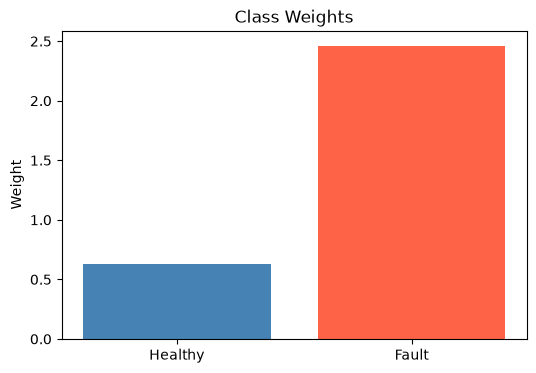

In [155]:
plt.figure(figsize=(6,4))

plt.bar(

    ["Healthy","Fault"],

    class_weights_m2.values(),

    color=["steelblue","tomato"]

)

plt.title("Class Weights")

plt.ylabel("Weight")

plt.show()

### Hyperparameter Tuning with Optuna (Model 2 — is_faulted)



In [156]:
X_tr_opt_m2, X_val_opt_m2, y_tr_opt_m2, y_val_opt_m2 = train_test_split(
    X_train_m2, y_train_m2, test_size=0.2, random_state=42, stratify=y_train_m2
)


In [157]:
def objective_cat_m2(trial):
    params = {
        "iterations": trial.suggest_int("iterations", 300, 800),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "depth": trial.suggest_int("depth", 4, 10),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 10.0, log=True),
        "loss_function": "Logloss",
        "eval_metric": "F1",
        "class_weights": class_weights_m2,
        "random_state": 42,
        "verbose": False
    }
    model = CatBoostClassifier(**params)
    model.fit(X_tr_opt_m2, y_tr_opt_m2, eval_set=(X_val_opt_m2, y_val_opt_m2),
              early_stopping_rounds=50, verbose=False)
    preds = model.predict(X_val_opt_m2)
    return f1_score(y_val_opt_m2, preds)

study_cat_m2 = optuna.create_study(direction="maximize", study_name="catboost_m2")
study_cat_m2.optimize(objective_cat_m2, n_trials=25, show_progress_bar=True)

best_params_cat_m2 = study_cat_m2.best_params
print("Best CatBoost (Model 2) params:", best_params_cat_m2)
print("Best validation F1:", study_cat_m2.best_value)


  0%|          | 0/25 [00:00<?, ?it/s]

Best CatBoost (Model 2) params: {'iterations': 669, 'learning_rate': 0.26910904962941584, 'depth': 10, 'l2_leaf_reg': 4.119958744989259}
Best validation F1: 0.9686704243083174


In [158]:

cat_model_m2 = CatBoostClassifier(

    **best_params_cat_m2,
    loss_function="Logloss",
    eval_metric="F1",
    class_weights=class_weights_m2,
    random_state=42,
    verbose=100

)

cat_model_m2.fit(

    X_train_m2,
    y_train_m2

)


0:	learn: 0.7943090	total: 174ms	remaining: 1m 55s
100:	learn: 0.9747998	total: 15.4s	remaining: 1m 26s
200:	learn: 0.9882649	total: 28.3s	remaining: 1m 5s
300:	learn: 0.9920797	total: 40.2s	remaining: 49.1s
400:	learn: 0.9920797	total: 50.4s	remaining: 33.7s
500:	learn: 0.9920797	total: 1m	remaining: 20.3s
600:	learn: 0.9920797	total: 1m 10s	remaining: 8.01s
668:	learn: 0.9920797	total: 1m 18s	remaining: 0us


CatBoostClassifier(class_weights={0: 0.6273622646691784, 1: 2.4629047948336282}, depth=10, eval_metric='F1', iterations=669, l2_leaf_reg=4.119958744989259, learning_rate=0.26910904962941584, loss_function='Logloss', random_state=42, verbose=100)

In [159]:
def objective_lgbm_m2(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 300, 800),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 4, 10),
        "num_leaves": trial.suggest_int("num_leaves", 20, 150),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "class_weight": class_weights_m2,
        "random_state": 42,
        "verbose": -1
    }
    model = LGBMClassifier(**params)
    model.fit(X_tr_opt_m2, y_tr_opt_m2)
    preds = model.predict(X_val_opt_m2)
    return f1_score(y_val_opt_m2, preds)

study_lgbm_m2 = optuna.create_study(direction="maximize", study_name="lgbm_m2")
study_lgbm_m2.optimize(objective_lgbm_m2, n_trials=25, show_progress_bar=True)

best_params_lgbm_m2 = study_lgbm_m2.best_params
print("Best LightGBM (Model 2) params:", best_params_lgbm_m2)
print("Best validation F1:", study_lgbm_m2.best_value)


  0%|          | 0/25 [00:00<?, ?it/s]

Best LightGBM (Model 2) params: {'n_estimators': 649, 'learning_rate': 0.29988145423500034, 'max_depth': 6, 'num_leaves': 65, 'subsample': 0.7073038515402565, 'colsample_bytree': 0.9931997633095833}
Best validation F1: 0.9708609271523179


In [160]:

lgbm_model_m2 = LGBMClassifier(

    **best_params_lgbm_m2,
    class_weight=class_weights_m2,
    random_state=42

)

lgbm_model_m2.fit(

    X_train_m2,
    y_train_m2

)


,num_leaves,65
,max_depth,6
,learning_rate,0.29988145423500034
,n_estimators,649
,class_weight,"{0: 0.6273622646691784, 1: 2.4629047948336282}"
,subsample,0.7073038515402565
,colsample_bytree,0.9931997633095833
,random_state,42
,boosting_type,'gbdt'
,subsample_for_bin,200000
,objective,None


In [161]:
pred_cat_m2 = cat_model_m2.predict(X_test_m2)

pred_lgbm_m2 = lgbm_model_m2.predict(X_test_m2)

In [162]:

print("=" * 80)
print("CatBoost Classification Report")
print("=" * 80)

print(classification_report(
    y_test_m2,
    pred_cat_m2,
    target_names=["Healthy", "Fault"],
    digits=4
))

print("\n")

print("=" * 80)
print("LightGBM Classification Report")
print("=" * 80)

print(classification_report(
    y_test_m2,
    pred_lgbm_m2,
    target_names=["Healthy", "Fault"],
    digits=4
))

CatBoost Classification Report
              precision    recall  f1-score   support

     Healthy     0.9983    0.9780    0.9880     83366
       Fault     0.9223    0.9936    0.9566     21959

    accuracy                         0.9812    105325
   macro avg     0.9603    0.9858    0.9723    105325
weighted avg     0.9824    0.9812    0.9815    105325



LightGBM Classification Report
              precision    recall  f1-score   support

     Healthy     0.9968    0.9863    0.9915     83366
       Fault     0.9499    0.9880    0.9686     21959

    accuracy                         0.9866    105325
   macro avg     0.9734    0.9872    0.9801    105325
weighted avg     0.9870    0.9866    0.9867    105325



### Ensemble: Blending CatBoost + LightGBM (Model 2 — is_faulted)

In [163]:
proba_cat_m2 = cat_model_m2.predict_proba(X_test_m2)[:, 1]
proba_lgb_m2 = lgbm_model_m2.predict_proba(X_test_m2)[:, 1]

proba_blend_m2 = (proba_cat_m2 + proba_lgb_m2) / 2
pred_blend_m2 = (proba_blend_m2 >= 0.5).astype(int)

print("=" * 80)
print("Blend (CatBoost + LightGBM) Classification Report")
print("=" * 80)

print(classification_report(
    y_test_m2,
    pred_blend_m2,
    target_names=["Healthy", "Fault"],
    digits=4
))


Blend (CatBoost + LightGBM) Classification Report
              precision    recall  f1-score   support

     Healthy     0.9985    0.9878    0.9931     83366
       Fault     0.9554    0.9943    0.9744     21959

    accuracy                         0.9891    105325
   macro avg     0.9769    0.9910    0.9838    105325
weighted avg     0.9895    0.9891    0.9892    105325



In [164]:

cm_cat = confusion_matrix(
    y_test_m2,
    pred_cat_m2
)

cm_lgb = confusion_matrix(
    y_test_m2,
    pred_lgbm_m2
)

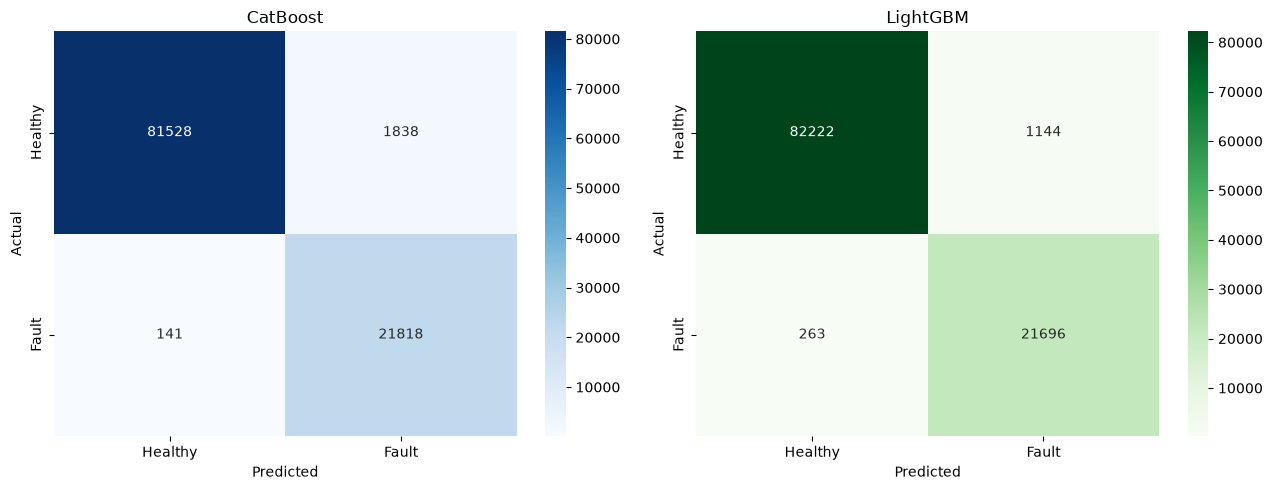

In [165]:
fig,axes = plt.subplots(
    1,
    2,
    figsize=(13,5)
)

sns.heatmap(
    cm_cat,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Healthy","Fault"],
    yticklabels=["Healthy","Fault"],
    ax=axes[0]
)

axes[0].set_title("CatBoost")

axes[0].set_xlabel("Predicted")

axes[0].set_ylabel("Actual")

sns.heatmap(
    cm_lgb,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Healthy","Fault"],
    yticklabels=["Healthy","Fault"],
    ax=axes[1]
)

axes[1].set_title("LightGBM")

axes[1].set_xlabel("Predicted")

axes[1].set_ylabel("Actual")

plt.tight_layout()

plt.show()

In [166]:
importance_cat = pd.DataFrame({

    "Feature":X_train_m2.columns,

    "Importance":cat_model_m2.get_feature_importance()

})

importance_cat = importance_cat.sort_values(
    by="Importance",
    ascending=False
)

importance_cat.head(10)

,Feature,Importance
4,module_temp,20.612937
6,dc_voltage,16.549227
19,month,11.916153
14,day_length_hours,10.168605
5,inverter_temp,9.230987
3,ambient_temp,8.105285
10,performance_ratio,6.005744
17,inverter_efficiency,5.559737
11,cloud_cover,2.793155
0,active_power,2.579146


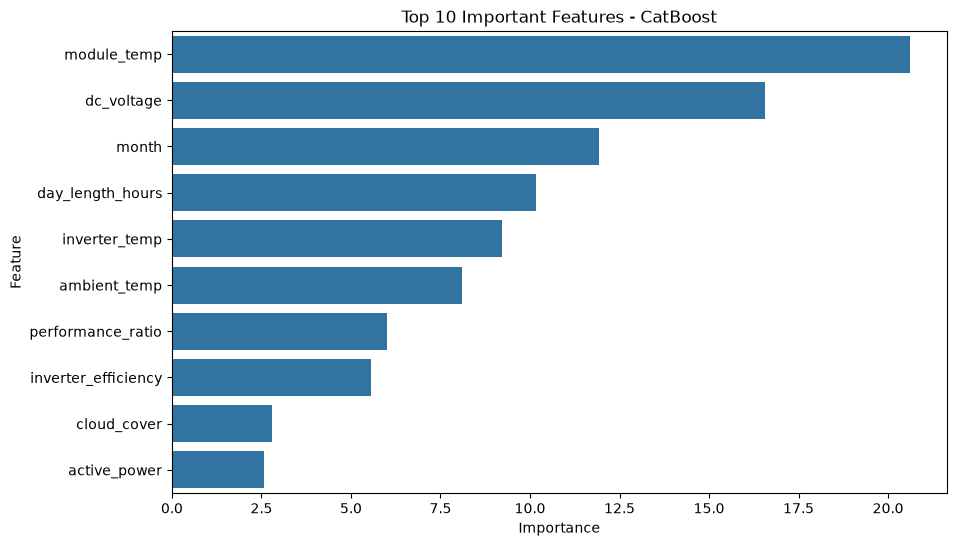

In [167]:
plt.figure(figsize=(10,6))

sns.barplot(

    data=importance_cat.head(10),

    x="Importance",

    y="Feature"

)

plt.title("Top 10 Important Features - CatBoost")

plt.show()

In [168]:
importance_lgb = pd.DataFrame({

    "Feature":X_train_m2.columns,

    "Importance":lgbm_model_m2.feature_importances_

})

importance_lgb = importance_lgb.sort_values(
    by="Importance",
    ascending=False
)

importance_lgb.head(10)

,Feature,Importance
4,module_temp,6233
3,ambient_temp,5748
11,cloud_cover,4491
5,inverter_temp,4398
14,day_length_hours,2662
2,clear_sky_irradiance,1745
12,sun_elevation,1735
6,dc_voltage,1622
13,sun_azimuth,1539
19,month,872


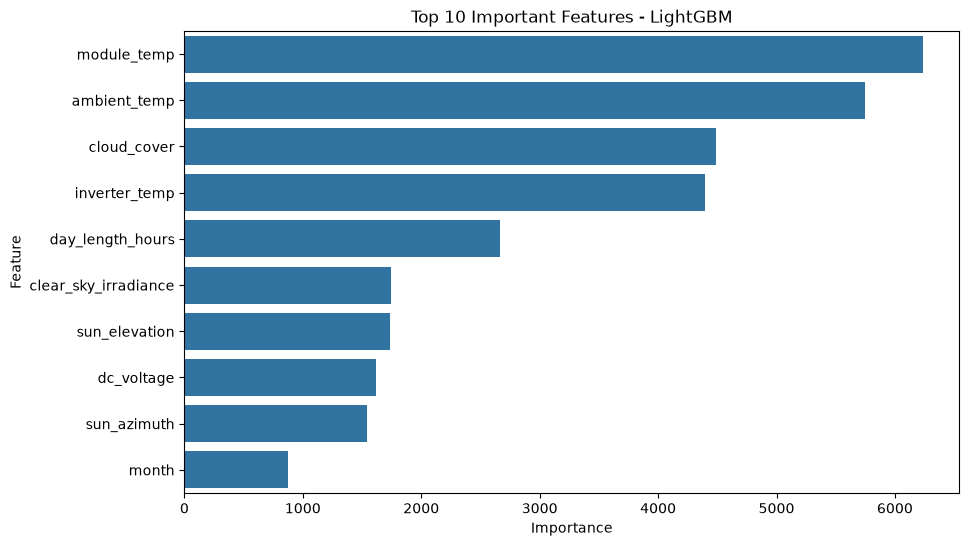

In [169]:
plt.figure(figsize=(10,6))

sns.barplot(

    data=importance_lgb.head(10),

    x="Importance",

    y="Feature"

)

plt.title("Top 10 Important Features - LightGBM")

plt.show()

## Model 3


In [170]:
model3_drop_cols = leakage_cols_general
model3_features = [c for c in df.columns if c not in model3_drop_cols]

X_train_m3 = train_df[model3_features]
y_train_m3 = train_df["fault_labels"]
X_test_m3 = test_df[model3_features]
y_test_m3 = test_df["fault_labels"]

excluded_label_m3 = "dc_string_outage|downtime"
train_mask_m3 = y_train_m3 != excluded_label_m3
test_mask_m3 = y_test_m3 != excluded_label_m3

X_train_m3 = X_train_m3[train_mask_m3]
y_train_m3 = y_train_m3[train_mask_m3]
X_test_m3 = X_test_m3[test_mask_m3]
y_test_m3 = y_test_m3[test_mask_m3]

print("Training samples :", X_train_m3.shape[0])
print("Testing samples  :", X_test_m3.shape[0])
print("Number of Features :", X_train_m3.shape[1])
print("\nTarget Distribution in Train Set:")
print(y_train_m3.value_counts())
print("\nTarget Distribution (%) in Train Set:")
print(round(y_train_m3.value_counts(normalize=True) * 100, 3))

Training samples : 420245
Testing samples  : 105301
Number of Features : 22

Target Distribution in Train Set:
fault_labels
healthy              334954
soiling               36787
tracker_stuck         32240
dc_string_outage      15629
inverter_overheat       449
downtime                186
Name: count, dtype: int64

Target Distribution (%) in Train Set:
fault_labels
healthy              79.704
soiling               8.754
tracker_stuck         7.672
dc_string_outage      3.719
inverter_overheat     0.107
downtime              0.044
Name: proportion, dtype: float64



Computed Class Weights:
dc_string_outage         : 4.4815
downtime                 : 376.5636
healthy                  : 0.2091
inverter_overheat        : 155.9929
soiling                  : 1.9040
tracker_stuck            : 2.1725


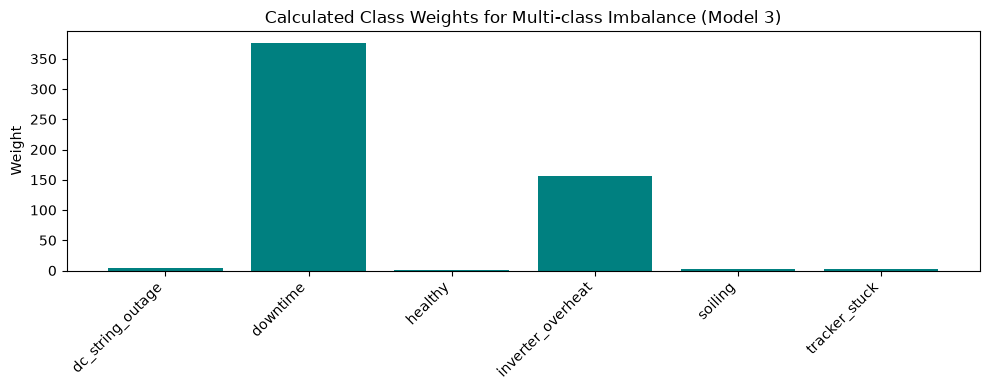

In [171]:
classes_m3 = np.unique(y_train_m3)
weights_m3 = compute_class_weight(
    class_weight="balanced", 
    classes=classes_m3, 
    y=y_train_m3
)
class_weights_m3 = dict(zip(classes_m3, weights_m3))

print("\nComputed Class Weights:")
for cls, w in class_weights_m3.items():
    print(f"{cls:25s}: {w:.4f}")

plt.figure(figsize=(10, 4))
plt.bar(class_weights_m3.keys(), class_weights_m3.values(), color="teal")
plt.title("Calculated Class Weights for Multi-class Imbalance (Model 3)")
plt.ylabel("Weight")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Hyperparameter Tuning with Optuna (Model 3 — fault_labels)

Optuna searches the space and keeps the params that maximize macro F1 on a held-out validation split.

In [172]:
X_tr_opt_m3, X_val_opt_m3, y_tr_opt_m3, y_val_opt_m3 = train_test_split(
    X_train_m3, y_train_m3, test_size=0.2, random_state=42, stratify=y_train_m3
)


In [173]:
def objective_cat_m3(trial):
    params = {
        "iterations": trial.suggest_int("iterations", 300, 800),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "depth": trial.suggest_int("depth", 4, 10),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 10.0, log=True),
        "loss_function": "MultiClass",
        "eval_metric": "TotalF1",
        "class_weights": class_weights_m3,
        "random_state": 42,
        "verbose": False
    }
    model = CatBoostClassifier(**params)
    model.fit(X_tr_opt_m3, y_tr_opt_m3, eval_set=(X_val_opt_m3, y_val_opt_m3),
              early_stopping_rounds=50, verbose=False)
    preds = model.predict(X_val_opt_m3)
    return f1_score(y_val_opt_m3, preds, average="macro")

study_cat_m3 = optuna.create_study(direction="maximize", study_name="catboost_m3")
study_cat_m3.optimize(objective_cat_m3, n_trials=25, show_progress_bar=True)

best_params_cat_m3 = study_cat_m3.best_params
print("Best CatBoost (Model 3) params:", best_params_cat_m3)
print("Best validation macro F1:", study_cat_m3.best_value)


  0%|          | 0/25 [00:00<?, ?it/s]

Best CatBoost (Model 3) params: {'iterations': 730, 'learning_rate': 0.20177906704546344, 'depth': 9, 'l2_leaf_reg': 1.9831737067505062}
Best validation macro F1: 0.9091348764734152


In [174]:

cat_model_m3 = CatBoostClassifier(
    **best_params_cat_m3,
    loss_function="MultiClass",
    eval_metric="TotalF1",
    class_weights=class_weights_m3,
    random_state=42,
    verbose=100
)

print("\nTraining CatBoost Model 3...")
cat_model_m3.fit(X_train_m3, y_train_m3)



Training CatBoost Model 3...
0:	learn: 0.7659766	total: 370ms	remaining: 4m 29s
100:	learn: 0.9700358	total: 32.3s	remaining: 3m 21s
200:	learn: 0.9814252	total: 1m 3s	remaining: 2m 45s
300:	learn: 0.9843165	total: 1m 36s	remaining: 2m 17s
400:	learn: 0.9867693	total: 2m 9s	remaining: 1m 45s
500:	learn: 0.9888751	total: 2m 41s	remaining: 1m 13s
600:	learn: 0.9905493	total: 3m 14s	remaining: 41.7s
700:	learn: 0.9917516	total: 3m 45s	remaining: 9.35s
729:	learn: 0.9920847	total: 3m 55s	remaining: 0us


CatBoostClassifier(class_weights={'dc_string_outage': 4.481466078017361, 'downtime': 376.56362007168457, 'healthy': 0.20910582746685616, 'inverter_overheat': 155.99294729027469, 'soiling': 1.9039561076829676, 'tracker_stuck': 2.172482423490488}, depth=9, eval_metric='TotalF1', iterations=730, l2_leaf_reg=1.9831737067505062, learning_rate=0.20177906704546344, loss_function='MultiClass', random_state=42, verbose=100)

In [175]:
def objective_lgbm_m3(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 300, 800),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 4, 10),
        "num_leaves": trial.suggest_int("num_leaves", 20, 150),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "objective": "multiclass",
        "class_weight": class_weights_m3,
        "random_state": 42,
        "verbose": -1
    }
    model = LGBMClassifier(**params)
    model.fit(X_tr_opt_m3, y_tr_opt_m3)
    preds = model.predict(X_val_opt_m3)
    return f1_score(y_val_opt_m3, preds, average="macro")

study_lgbm_m3 = optuna.create_study(direction="maximize", study_name="lgbm_m3")
study_lgbm_m3.optimize(objective_lgbm_m3, n_trials=25, show_progress_bar=True)

best_params_lgbm_m3 = study_lgbm_m3.best_params
print("Best LightGBM (Model 3) params:", best_params_lgbm_m3)
print("Best validation macro F1:", study_lgbm_m3.best_value)


  0%|          | 0/25 [00:00<?, ?it/s]

Best LightGBM (Model 3) params: {'n_estimators': 792, 'learning_rate': 0.104958414902571, 'max_depth': 10, 'num_leaves': 72, 'subsample': 0.7231310093381045, 'colsample_bytree': 0.8368137699298739}
Best validation macro F1: 0.9628589673958402


In [176]:

lgbm_model_m3 = LGBMClassifier(
    **best_params_lgbm_m3,
    objective="multiclass",
    class_weight=class_weights_m3,
    random_state=42
)

print("\nTraining LightGBM Model 3...")
lgbm_model_m3.fit(X_train_m3, y_train_m3)



Training LightGBM Model 3...


,num_leaves,72
,max_depth,10
,learning_rate,0.104958414902571
,n_estimators,792
,objective,'multiclass'
,class_weight,"{'dc_string_outage': 4.481466078017361, 'downtime': 376.56362007168457, 'healthy': 0.20910582746685616, 'inverter_overheat': 155.99294729027469, ...}"
,subsample,0.7231310093381045
,colsample_bytree,0.8368137699298739
,random_state,42
,boosting_type,'gbdt'
,subsample_for_bin,200000


In [177]:
pred_cat_m3 = cat_model_m3.predict(X_test_m3).ravel()
pred_lgb_m3 = lgbm_model_m3.predict(X_test_m3)

In [178]:
print("=" * 80)
print("CatBoost Model 3 - Classification Report")
print("=" * 80)
print(classification_report(y_test_m3, pred_cat_m3, digits=4))

print("=" * 80)
print("LightGBM Model 3 - Classification Report")
print("=" * 80)
print(classification_report(y_test_m3, pred_lgb_m3, digits=4))

CatBoost Model 3 - Classification Report
                   precision    recall  f1-score   support

 dc_string_outage     0.9881    0.9996    0.9938      4477
         downtime     0.0000    0.0000    0.0000        15
          healthy     0.9991    0.9482    0.9730     83366
inverter_overheat     0.8353    1.0000    0.9103        71
          soiling     0.7336    0.9855    0.8411      9292
    tracker_stuck     0.8859    0.9963    0.9378      8080

         accuracy                         0.9573    105301
        macro avg     0.7403    0.8216    0.7760    105301
     weighted avg     0.9663    0.9573    0.9594    105301

LightGBM Model 3 - Classification Report


/usr/local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


                   precision    recall  f1-score   support

 dc_string_outage     0.9980    0.9991    0.9985      4477
         downtime     0.0000    0.0000    0.0000        15
          healthy     0.9965    0.9849    0.9907     83366
inverter_overheat     0.9221    1.0000    0.9595        71
          soiling     0.8868    0.9691    0.9261      9292
    tracker_stuck     0.9773    0.9908    0.9840      8080

         accuracy                         0.9844    105301
        macro avg     0.7968    0.8240    0.8098    105301
     weighted avg     0.9852    0.9844    0.9846    105301



/usr/local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


### Ensemble: Blending CatBoost + LightGBM (Model 3 — fault_labels)

In [179]:
def blend_multiclass_proba(cat_model, lgb_model, X_test, classes_order):
    """Average CatBoost + LightGBM probabilities, aligning columns by class label."""
    proba_cat = cat_model.predict_proba(X_test)
    proba_lgb = lgb_model.predict_proba(X_test)

    cat_classes = list(cat_model.classes_.ravel())
    lgb_classes = list(lgb_model.classes_)

    proba_cat_df = pd.DataFrame(proba_cat, columns=cat_classes)[classes_order]
    proba_lgb_df = pd.DataFrame(proba_lgb, columns=lgb_classes)[classes_order]

    proba_blend = (proba_cat_df.values + proba_lgb_df.values) / 2
    pred_blend = pd.Series(proba_blend.argmax(axis=1)).map(dict(enumerate(classes_order))).values
    return pred_blend, proba_blend


pred_blend_m3, proba_blend_m3 = blend_multiclass_proba(
    cat_model_m3, lgbm_model_m3, X_test_m3, list(classes_m3)
)

print("=" * 80)
print("Blend (CatBoost + LightGBM) - Model 3 Classification Report")
print("=" * 80)
print(classification_report(y_test_m3, pred_blend_m3, digits=4))


Blend (CatBoost + LightGBM) - Model 3 Classification Report


/usr/local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


                   precision    recall  f1-score   support

 dc_string_outage     0.9984    1.0000    0.9992      4477
         downtime     0.0000    0.0000    0.0000        15
          healthy     0.9985    0.9787    0.9885     83366
inverter_overheat     0.9221    1.0000    0.9595        71
          soiling     0.8496    0.9830    0.9114      9292
    tracker_stuck     0.9726    0.9957    0.9840      8080

         accuracy                         0.9812    105301
        macro avg     0.7902    0.8262    0.8071    105301
     weighted avg     0.9832    0.9812    0.9817    105301



/usr/local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


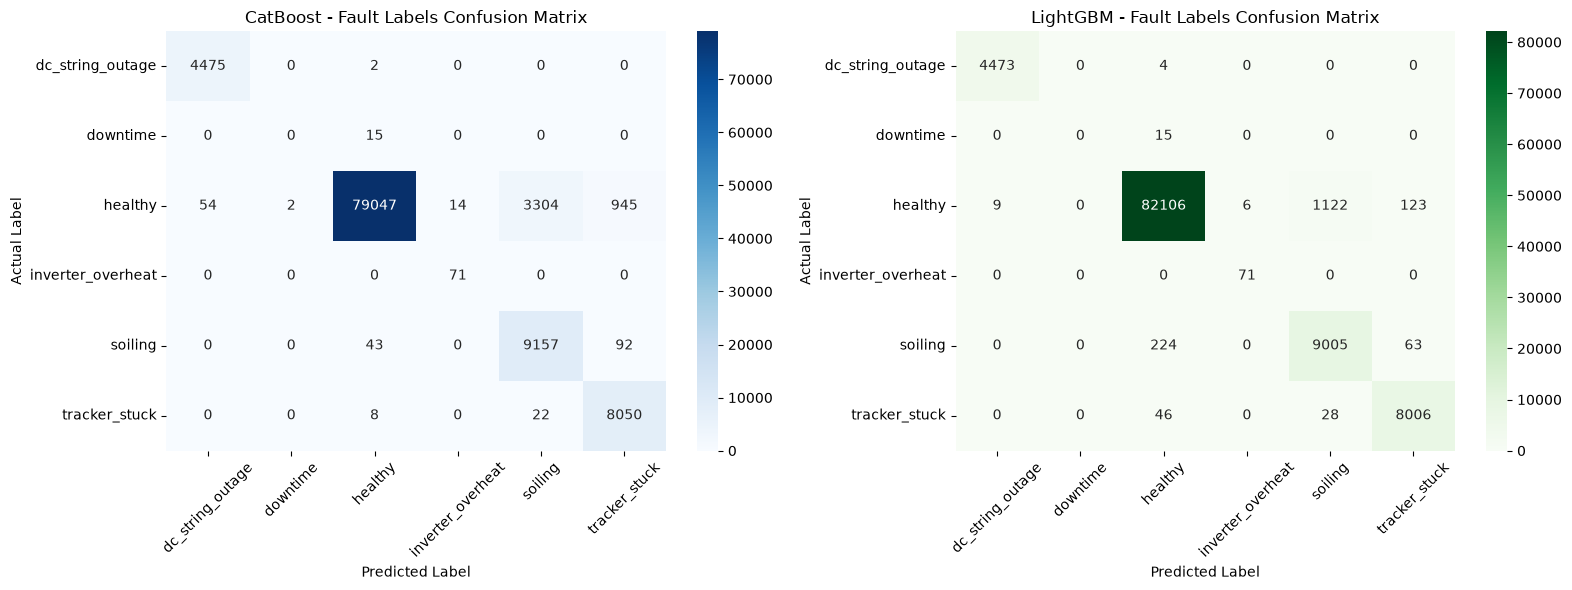

In [180]:
cm_cat_m3 = confusion_matrix(y_test_m3, pred_cat_m3, labels=classes_m3)
cm_lgb_m3 = confusion_matrix(y_test_m3, pred_lgb_m3, labels=classes_m3)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(
    cm_cat_m3, annot=True, fmt="d", cmap="Blues",
    xticklabels=classes_m3, yticklabels=classes_m3, ax=axes[0]
)
axes[0].set_title("CatBoost - Fault Labels Confusion Matrix")
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("Actual Label")
axes[0].tick_params(axis='x', rotation=45)

sns.heatmap(
    cm_lgb_m3, annot=True, fmt="d", cmap="Greens",
    xticklabels=classes_m3, yticklabels=classes_m3, ax=axes[1]
)
axes[1].set_title("LightGBM - Fault Labels Confusion Matrix")
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("Actual Label")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

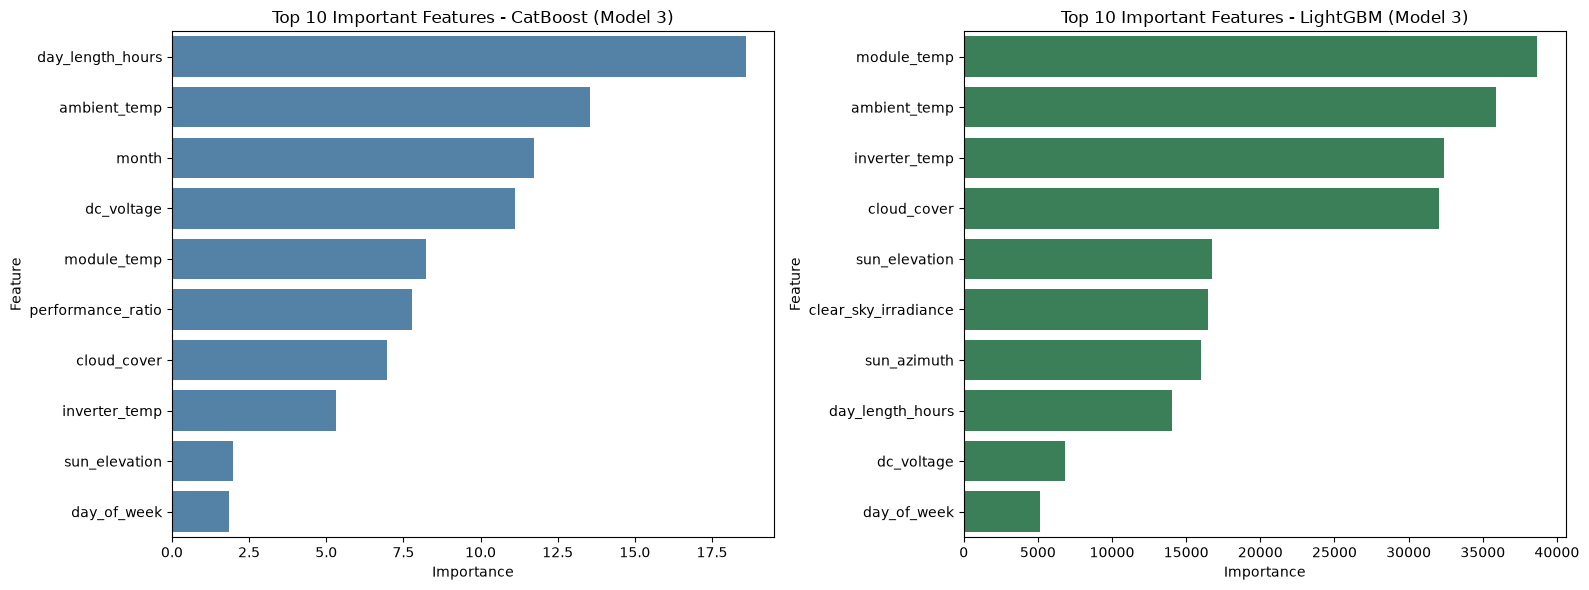

In [181]:
importance_cat_m3 = pd.DataFrame({
    "Feature": X_train_m3.columns,
    "Importance": cat_model_m3.get_feature_importance()
}).sort_values(by="Importance", ascending=False)

importance_lgb_m3 = pd.DataFrame({
    "Feature": X_train_m3.columns,
    "Importance": lgbm_model_m3.feature_importances_
}).sort_values(by="Importance", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=importance_cat_m3.head(10), x="Importance", y="Feature", ax=axes[0], color="steelblue")
axes[0].set_title("Top 10 Important Features - CatBoost (Model 3)")

sns.barplot(data=importance_lgb_m3.head(10), x="Importance", y="Feature", ax=axes[1], color="seagreen")
axes[1].set_title("Top 10 Important Features - LightGBM (Model 3)")

plt.tight_layout()
plt.show()

## Model 4

In [182]:
print("=" * 70)
print("MODEL 4 : Fault Severity Detection")
print("=" * 70)
print()
print("Training samples :", X_train_m4.shape[0])
print("Testing samples :", X_test_m4.shape[0])
print("Number of Features :", X_train_m4.shape[1])
print("\nTarget Distribution in Train Set:")
print(y_train_m4.value_counts())
print("\nTarget Distribution (%) in Train Set:")
print(round(y_train_m4.value_counts(normalize=True) * 100, 3))

MODEL 4 : Fault Severity Detection

Training samples : 420275
Testing samples : 105325
Number of Features : 22

Target Distribution in Train Set:
fault_severity
0    334954
3     79600
2      3014
1      2707
Name: count, dtype: int64

Target Distribution (%) in Train Set:
fault_severity
0    79.699
3    18.940
2     0.717
1     0.644
Name: proportion, dtype: float64



Computed Class Weights for Model 4:
Class 0: 0.3137
Class 1: 38.8137
Class 2: 34.8602
Class 3: 1.3200


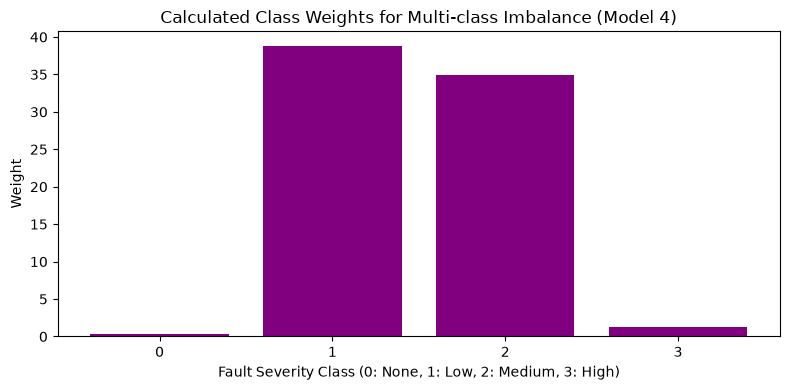

In [183]:
classes_m4 = np.unique(y_train_m4)
weights_m4 = compute_class_weight(
    class_weight="balanced",
    classes=classes_m4,
    y=y_train_m4
)
class_weights_m4 = dict(zip(classes_m4, weights_m4))

print("\nComputed Class Weights for Model 4:")
for cls, w in class_weights_m4.items():
    print(f"Class {cls}: {w:.4f}")

plt.figure(figsize=(8, 4))
plt.bar([str(c) for c in class_weights_m4.keys()], class_weights_m4.values(), color="purple")
plt.title("Calculated Class Weights for Multi-class Imbalance (Model 4)")
plt.xlabel("Fault Severity Class (0: None, 1: Low, 2: Medium, 3: High)")
plt.ylabel("Weight")
plt.tight_layout()
plt.show()

### Hyperparameter Tuning with Optuna (Model 4 — fault_severity)

Same idea: Optuna explores thousands of possible combinations and keeps the one that maximizes macro F1 on a validation split.

In [184]:
X_tr_opt_m4, X_val_opt_m4, y_tr_opt_m4, y_val_opt_m4 = train_test_split(
    X_train_m4, y_train_m4, test_size=0.2, random_state=42, stratify=y_train_m4
)


In [185]:
def objective_cat_m4(trial):
    params = {
        "iterations": trial.suggest_int("iterations", 300, 800),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "depth": trial.suggest_int("depth", 4, 10),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 10.0, log=True),
        "loss_function": "MultiClass",
        "eval_metric": "TotalF1",
        "class_weights": class_weights_m4,
        "random_state": 42,
        "verbose": False
    }
    model = CatBoostClassifier(**params)
    model.fit(X_tr_opt_m4, y_tr_opt_m4, eval_set=(X_val_opt_m4, y_val_opt_m4),
              early_stopping_rounds=50, verbose=False)
    preds = model.predict(X_val_opt_m4)
    return f1_score(y_val_opt_m4, preds, average="macro")

study_cat_m4 = optuna.create_study(direction="maximize", study_name="catboost_m4")
study_cat_m4.optimize(objective_cat_m4, n_trials=25, show_progress_bar=True)

best_params_cat_m4 = study_cat_m4.best_params
print("Best CatBoost (Model 4) params:", best_params_cat_m4)
print("Best validation macro F1:", study_cat_m4.best_value)


  0%|          | 0/25 [00:00<?, ?it/s]

Best CatBoost (Model 4) params: {'iterations': 798, 'learning_rate': 0.29791077082321704, 'depth': 8, 'l2_leaf_reg': 3.74912162221112}
Best validation macro F1: 0.891058731441555


In [186]:

cat_model_m4 = CatBoostClassifier(
    **best_params_cat_m4,
    loss_function="MultiClass",
    eval_metric="TotalF1",
    class_weights=class_weights_m4,
    random_state=42,
    verbose=100
)

print("\nTraining CatBoost Model 4...")
cat_model_m4.fit(X_train_m4, y_train_m4)



Training CatBoost Model 4...
0:	learn: 0.8136640	total: 276ms	remaining: 3m 39s
100:	learn: 0.9705223	total: 17s	remaining: 1m 57s
200:	learn: 0.9784907	total: 33.1s	remaining: 1m 38s
300:	learn: 0.9835119	total: 49.1s	remaining: 1m 20s
400:	learn: 0.9869603	total: 1m 4s	remaining: 1m 4s
500:	learn: 0.9892780	total: 1m 20s	remaining: 47.8s
600:	learn: 0.9908936	total: 1m 36s	remaining: 31.6s
700:	learn: 0.9920469	total: 1m 52s	remaining: 15.5s
797:	learn: 0.9928246	total: 2m 7s	remaining: 0us


CatBoostClassifier(class_weights={0: 0.3136811323345892, 1: 38.813723679349835, 2: 34.860235567352355, 3: 1.3199591708542713}, depth=8, eval_metric='TotalF1', iterations=798, l2_leaf_reg=3.74912162221112, learning_rate=0.29791077082321704, loss_function='MultiClass', random_state=42, verbose=100)

In [187]:
def objective_lgbm_m4(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 300, 800),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 4, 10),
        "num_leaves": trial.suggest_int("num_leaves", 20, 150),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "objective": "multiclass",
        "class_weight": class_weights_m4,
        "random_state": 42,
        "verbose": -1
    }
    model = LGBMClassifier(**params)
    model.fit(X_tr_opt_m4, y_tr_opt_m4)
    preds = model.predict(X_val_opt_m4)
    return f1_score(y_val_opt_m4, preds, average="macro")

study_lgbm_m4 = optuna.create_study(direction="maximize", study_name="lgbm_m4")
study_lgbm_m4.optimize(objective_lgbm_m4, n_trials=25, show_progress_bar=True)

best_params_lgbm_m4 = study_lgbm_m4.best_params
print("Best LightGBM (Model 4) params:", best_params_lgbm_m4)
print("Best validation macro F1:", study_lgbm_m4.best_value)


  0%|          | 0/25 [00:00<?, ?it/s]

Best LightGBM (Model 4) params: {'n_estimators': 757, 'learning_rate': 0.13826525758325292, 'max_depth': 9, 'num_leaves': 125, 'subsample': 0.8673040834923631, 'colsample_bytree': 0.9627715688241893}
Best validation macro F1: 0.9545018842507722


In [188]:

lgbm_model_m4 = LGBMClassifier(
    **best_params_lgbm_m4,
    objective="multiclass",
    class_weight=class_weights_m4,
    random_state=42
)

print("\nTraining LightGBM Model 4...")
lgbm_model_m4.fit(X_train_m4, y_train_m4)



Training LightGBM Model 4...


,num_leaves,125
,max_depth,9
,learning_rate,0.13826525758325292
,n_estimators,757
,objective,'multiclass'
,class_weight,"{0: 0.3136811323345892, 1: 38.813723679349835, 2: 34.860235567352355, 3: 1.3199591708542713}"
,subsample,0.8673040834923631
,colsample_bytree,0.9627715688241893
,random_state,42
,boosting_type,'gbdt'
,subsample_for_bin,200000


In [189]:
pred_cat_m4 = cat_model_m4.predict(X_test_m4).ravel()
pred_lgb_m4 = lgbm_model_m4.predict(X_test_m4)

print("\n" + "=" * 80)
print("CatBoost Model 4 - Classification Report")
print("=" * 80)
print(classification_report(y_test_m4, pred_cat_m4, digits=4))

print("=" * 80)
print("LightGBM Model 4 - Classification Report")
print("=" * 80)
print(classification_report(y_test_m4, pred_lgb_m4, digits=4))


CatBoost Model 4 - Classification Report
              precision    recall  f1-score   support

           0     0.9980    0.9662    0.9819     83366
           1     0.6516    0.9964    0.7880       841
           2     0.5959    1.0000    0.7468       410
           3     0.8999    0.9841    0.9401     20708

    accuracy                         0.9701    105325
   macro avg     0.7864    0.9867    0.8642    105325
weighted avg     0.9744    0.9701    0.9712    105325

LightGBM Model 4 - Classification Report
              precision    recall  f1-score   support

           0     0.9946    0.9903    0.9925     83366
           1     0.8821    0.8989    0.8905       841
           2     0.8851    0.9585    0.9204       410
           3     0.9642    0.9787    0.9714     20708

    accuracy                         0.9872    105325
   macro avg     0.9315    0.9566    0.9437    105325
weighted avg     0.9873    0.9872    0.9872    105325



### Ensemble: Blending CatBoost + LightGBM (Model 4 — fault_severity)

In [190]:
pred_blend_m4, proba_blend_m4 = blend_multiclass_proba(
    cat_model_m4, lgbm_model_m4, X_test_m4, list(classes_m4)
)

print("=" * 80)
print("Blend (CatBoost + LightGBM) - Model 4 Classification Report")
print("=" * 80)
print(classification_report(y_test_m4, pred_blend_m4, digits=4))


Blend (CatBoost + LightGBM) - Model 4 Classification Report
              precision    recall  f1-score   support

           0     0.9972    0.9877    0.9924     83366
           1     0.8328    0.9655    0.8943       841
           2     0.8272    0.9927    0.9024       410
           3     0.9597    0.9865    0.9729     20708

    accuracy                         0.9873    105325
   macro avg     0.9042    0.9831    0.9405    105325
weighted avg     0.9878    0.9873    0.9874    105325



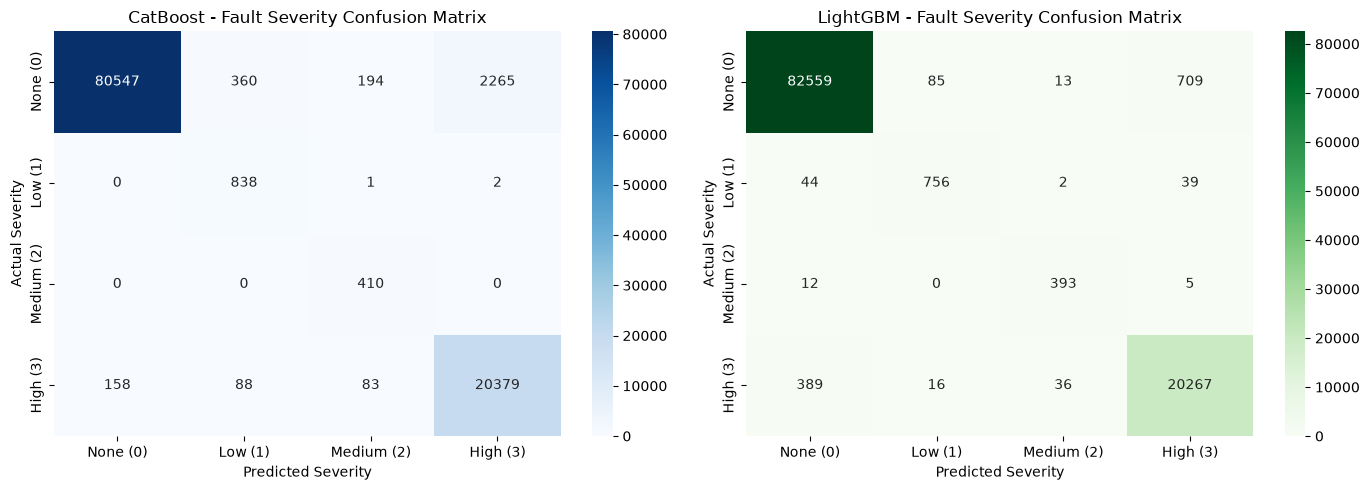

In [191]:
cm_cat_m4 = confusion_matrix(y_test_m4, pred_cat_m4, labels=classes_m4)
cm_lgb_m4 = confusion_matrix(y_test_m4, pred_lgb_m4, labels=classes_m4)

severity_labels = ["None (0)", "Low (1)", "Medium (2)", "High (3)"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(
    cm_cat_m4, annot=True, fmt="d", cmap="Blues",
    xticklabels=severity_labels, yticklabels=severity_labels, ax=axes[0]
)
axes[0].set_title("CatBoost - Fault Severity Confusion Matrix")
axes[0].set_xlabel("Predicted Severity")
axes[0].set_ylabel("Actual Severity")

sns.heatmap(
    cm_lgb_m4, annot=True, fmt="d", cmap="Greens",
    xticklabels=severity_labels, yticklabels=severity_labels, ax=axes[1]
)
axes[1].set_title("LightGBM - Fault Severity Confusion Matrix")
axes[1].set_xlabel("Predicted Severity")
axes[1].set_ylabel("Actual Severity")

plt.tight_layout()
plt.show()

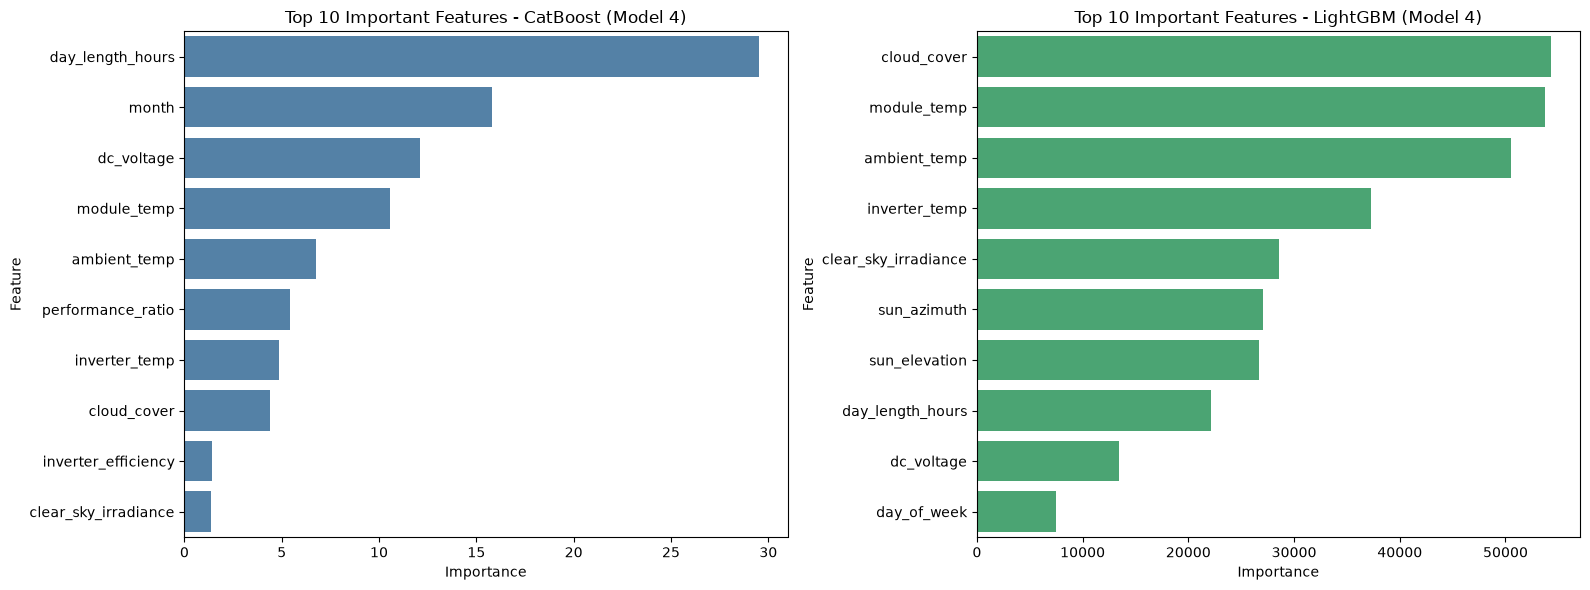

In [192]:
importance_cat_m4 = pd.DataFrame({
    "Feature": X_train_m4.columns,
    "Importance": cat_model_m4.get_feature_importance()
}).sort_values(by="Importance", ascending=False)

importance_lgb_m4 = pd.DataFrame({
    "Feature": X_train_m4.columns,
    "Importance": lgbm_model_m4.feature_importances_
}).sort_values(by="Importance", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=importance_cat_m4.head(10), x="Importance", y="Feature", ax=axes[0], color="steelblue")
axes[0].set_title("Top 10 Important Features - CatBoost (Model 4)")

sns.barplot(data=importance_lgb_m4.head(10), x="Importance", y="Feature", ax=axes[1], color="mediumseagreen")
axes[1].set_title("Top 10 Important Features - LightGBM (Model 4)")

plt.tight_layout()
plt.show()

## Evaluate all Models



MODEL 1 (Regression - active_power) IS EVALUATED SEPARATELY WITH MAE / RMSE / R2


,Model,MAE,RMSE,R2
0,CatBoost,16.992747,62.202964,0.996940
1,LightGBM,15.041408,65.272511,0.996630
2,Blend (Simple Avg),14.689190,60.626787,0.997093
3,Blend (Weighted),15.133416,60.431331,0.997111


COMPREHENSIVE MODELS EVALUATION SUMMARY (Classification Models: 2, 3, 4)


,Model Task,Algorithm,Accuracy,F1-Score (Macro),F1-Score (Weighted)
0,Model 2: Fault Cause,CatBoost,0.9812,0.9723,0.9815
1,Model 2: Fault Cause,LightGBM,0.9866,0.9801,0.9867
2,Model 3: Component at Fault,CatBoost,0.9573,0.7760,0.9594
3,Model 3: Component at Fault,LightGBM,0.9844,0.8098,0.9846
4,Model 4: Fault Severity,CatBoost,0.9701,0.8642,0.9712
5,Model 4: Fault Severity,LightGBM,0.9872,0.9437,0.9872


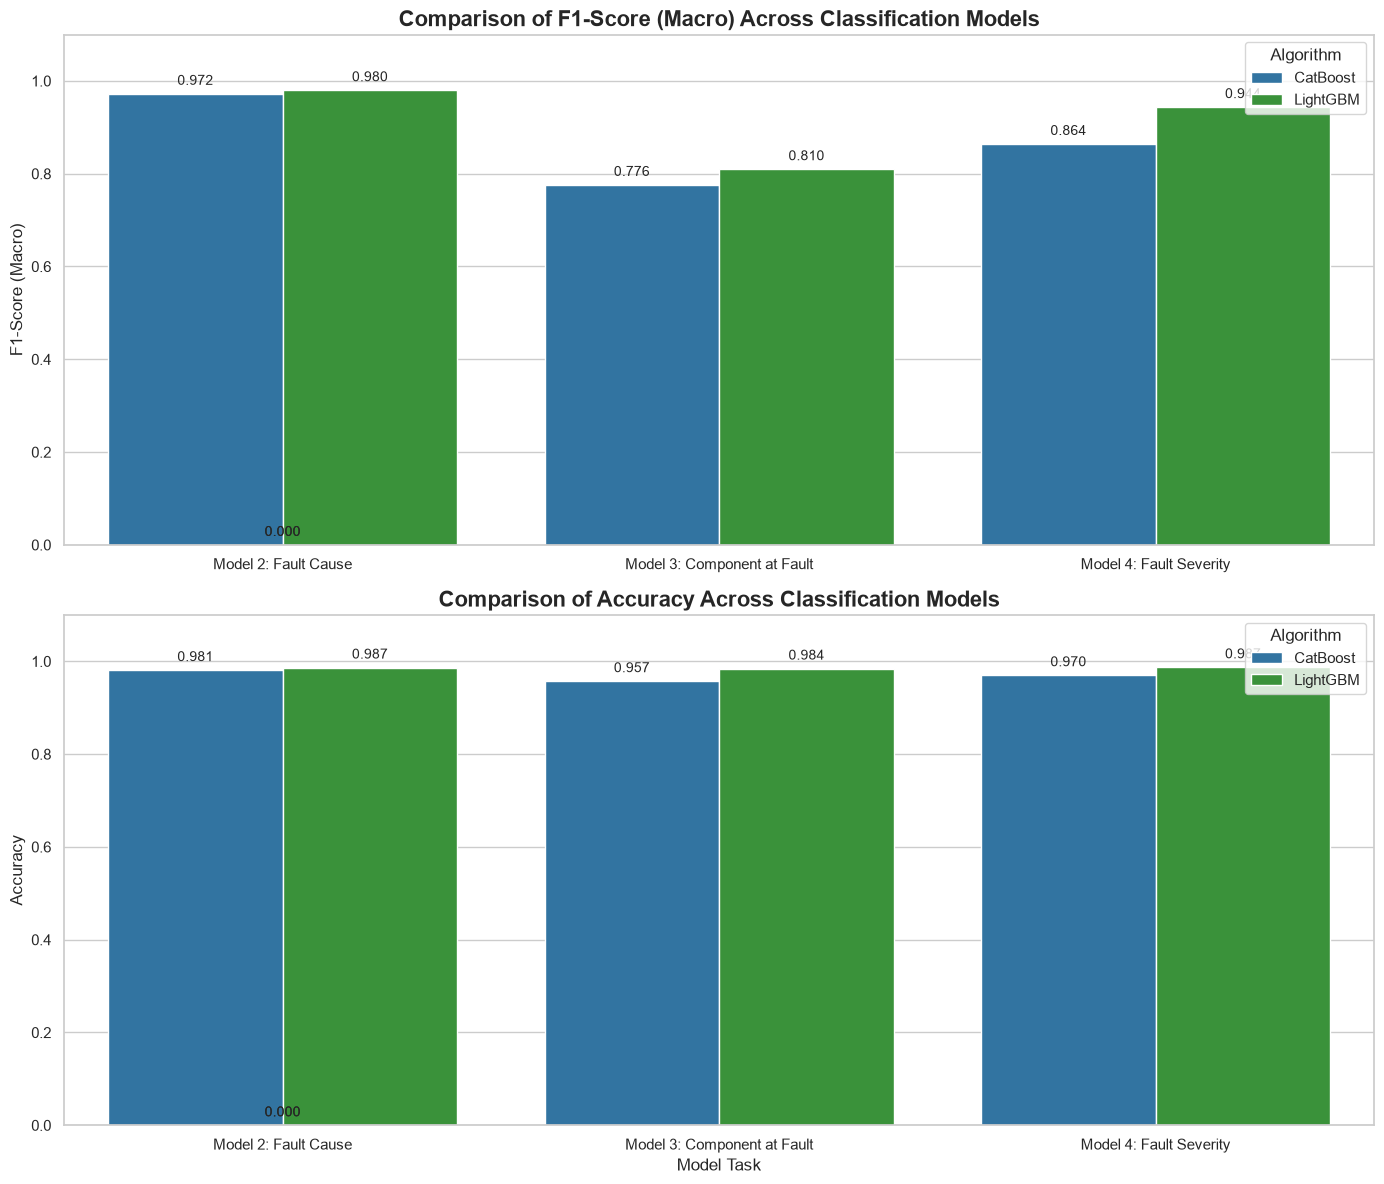

In [193]:
models_info = [
    ("Model 2: Fault Cause", y_test_m2, pred_cat_m2, pred_lgbm_m2),
    ("Model 3: Component at Fault", y_test_m3, pred_cat_m3, pred_lgb_m3),
    ("Model 4: Fault Severity", y_test_m4, pred_cat_m4, pred_lgb_m4)
]

evaluation_results = []

for model_name, y_true, pred_cat, pred_lgb in models_info:

    acc_cat = accuracy_score(y_true, pred_cat)
    f1_macro_cat = f1_score(y_true, pred_cat, average='macro')
    f1_weighted_cat = f1_score(y_true, pred_cat, average='weighted')

    evaluation_results.append({
        "Model Task": model_name,
        "Algorithm": "CatBoost",
        "Accuracy": acc_cat,
        "F1-Score (Macro)": f1_macro_cat,
        "F1-Score (Weighted)": f1_weighted_cat
    })

    acc_lgb = accuracy_score(y_true, pred_lgb)
    f1_macro_lgb = f1_score(y_true, pred_lgb, average='macro')
    f1_weighted_lgb = f1_score(y_true, pred_lgb, average='weighted')

    evaluation_results.append({
        "Model Task": model_name,
        "Algorithm": "LightGBM",
        "Accuracy": acc_lgb,
        "F1-Score (Macro)": f1_macro_lgb,
        "F1-Score (Weighted)": f1_weighted_lgb
    })

results_df = pd.DataFrame(evaluation_results)

print("=" * 85)
print("MODEL 1 (Regression - active_power) IS EVALUATED SEPARATELY WITH MAE / RMSE / R2")
print("=" * 85)
display(results_m1_df)

print("=" * 85)
print("COMPREHENSIVE MODELS EVALUATION SUMMARY (Classification Models: 2, 3, 4)")
print("=" * 85)
display(results_df.style.format({
    "Accuracy": "{:.4f}",
    "F1-Score (Macro)": "{:.4f}",
    "F1-Score (Weighted)": "{:.4f}"
}).background_gradient(cmap='viridis', subset=['F1-Score (Macro)', 'Accuracy']))

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(2, 1, figsize=(14, 12))

sns.barplot(
    data=results_df,
    x="Model Task",
    y="F1-Score (Macro)",
    hue="Algorithm",
    palette=["#1f77b4", "#2ca02c"],
    ax=axes[0]
)
axes[0].set_title("Comparison of F1-Score (Macro) Across Classification Models", fontsize=16, fontweight='bold')
axes[0].set_ylabel("F1-Score (Macro)", fontsize=12)
axes[0].set_xlabel("")
axes[0].set_ylim(0, 1.1)
axes[0].legend(title="Algorithm", loc='upper right')

for p in axes[0].patches:
    axes[0].annotate(format(p.get_height(), '.3f'),
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha = 'center', va = 'center',
                     xytext = (0, 9),
                     textcoords = 'offset points',
                     fontsize=10)

sns.barplot(
    data=results_df,
    x="Model Task",
    y="Accuracy",
    hue="Algorithm",
    palette=["#1f77b4", "#2ca02c"],
    ax=axes[1]
)
axes[1].set_title("Comparison of Accuracy Across Classification Models", fontsize=16, fontweight='bold')
axes[1].set_ylabel("Accuracy", fontsize=12)
axes[1].set_xlabel("Model Task", fontsize=12)
axes[1].set_ylim(0, 1.1)
axes[1].legend(title="Algorithm", loc='upper right')

for p in axes[1].patches:
    axes[1].annotate(format(p.get_height(), '.3f'),
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha = 'center', va = 'center',
                     xytext = (0, 9),
                     textcoords = 'offset points',
                     fontsize=10)

plt.tight_layout()
plt.show()

## Ensemble (Blend) vs Individual Models — Final Comparison

FINAL COMPARISON: CatBoost vs LightGBM vs Blend


,Model Task,Algorithm,Accuracy,F1-Score (Macro),F1-Score (Weighted)
0,Model 2: Fault Cause,CatBoost,0.9812,0.9723,0.9815
1,Model 2: Fault Cause,LightGBM,0.9866,0.9801,0.9867
2,Model 3: Component at Fault,CatBoost,0.9573,0.7760,0.9594
3,Model 3: Component at Fault,LightGBM,0.9844,0.8098,0.9846
4,Model 4: Fault Severity,CatBoost,0.9701,0.8642,0.9712
5,Model 4: Fault Severity,LightGBM,0.9872,0.9437,0.9872
6,Model 2: Fault Cause,Blend (Cat+LGBM),0.9891,0.9838,0.9892
7,Model 3: Component at Fault,Blend (Cat+LGBM),0.9812,0.8071,0.9817
8,Model 4: Fault Severity,Blend (Cat+LGBM),0.9873,0.9405,0.9874


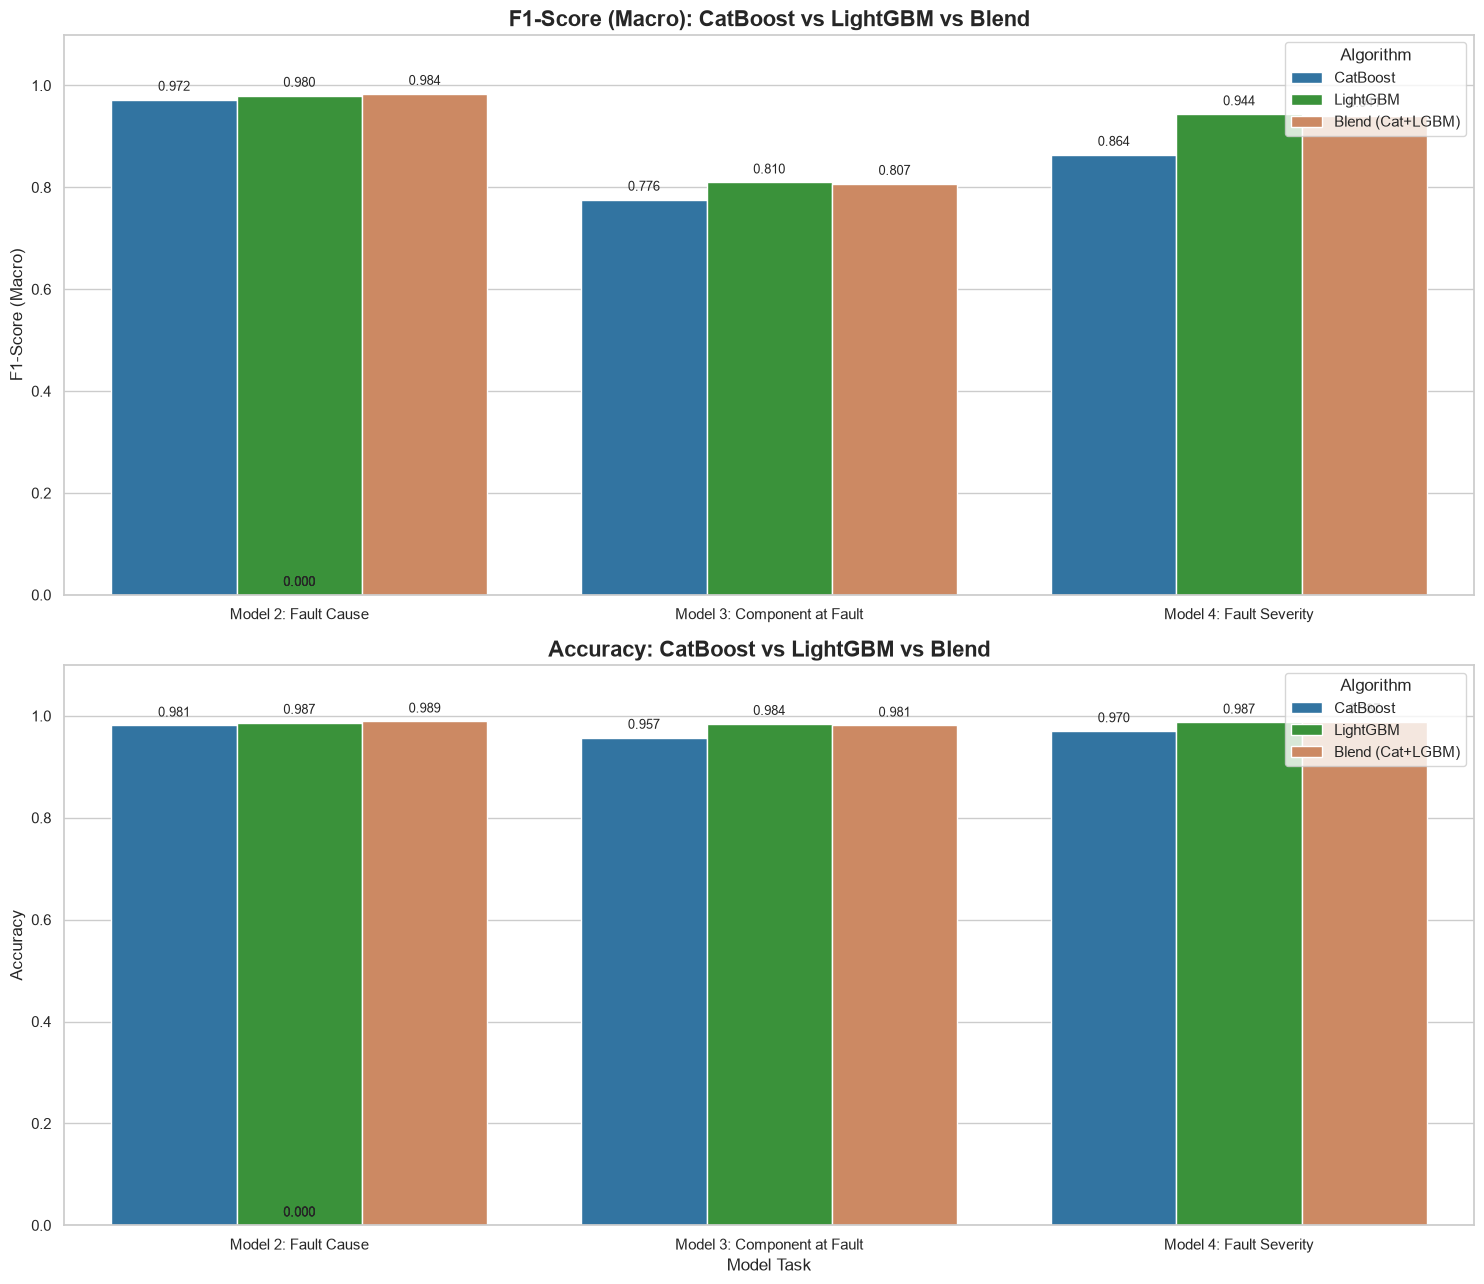

In [194]:
blend_results = [
    {
        "Model Task": "Model 2: Fault Cause",
        "Algorithm": "Blend (Cat+LGBM)",
        "Accuracy": accuracy_score(y_test_m2, pred_blend_m2),
        "F1-Score (Macro)": f1_score(y_test_m2, pred_blend_m2, average='macro'),
        "F1-Score (Weighted)": f1_score(y_test_m2, pred_blend_m2, average='weighted'),
    },
    {
        "Model Task": "Model 3: Component at Fault",
        "Algorithm": "Blend (Cat+LGBM)",
        "Accuracy": accuracy_score(y_test_m3, pred_blend_m3),
        "F1-Score (Macro)": f1_score(y_test_m3, pred_blend_m3, average='macro'),
        "F1-Score (Weighted)": f1_score(y_test_m3, pred_blend_m3, average='weighted'),
    },
    {
        "Model Task": "Model 4: Fault Severity",
        "Algorithm": "Blend (Cat+LGBM)",
        "Accuracy": accuracy_score(y_test_m4, pred_blend_m4),
        "F1-Score (Macro)": f1_score(y_test_m4, pred_blend_m4, average='macro'),
        "F1-Score (Weighted)": f1_score(y_test_m4, pred_blend_m4, average='weighted'),
    },
]

results_df_with_blend = pd.concat([results_df, pd.DataFrame(blend_results)], ignore_index=True)

print("=" * 85)
print("FINAL COMPARISON: CatBoost vs LightGBM vs Blend")
print("=" * 85)
display(results_df_with_blend.style.format({
    "Accuracy": "{:.4f}",
    "F1-Score (Macro)": "{:.4f}",
    "F1-Score (Weighted)": "{:.4f}"
}).background_gradient(cmap='viridis', subset=['F1-Score (Macro)', 'Accuracy']))

fig, axes = plt.subplots(2, 1, figsize=(15, 13))

sns.barplot(
    data=results_df_with_blend,
    x="Model Task",
    y="F1-Score (Macro)",
    hue="Algorithm",
    palette=["#1f77b4", "#2ca02c", "#DD8452"],
    ax=axes[0]
)
axes[0].set_title("F1-Score (Macro): CatBoost vs LightGBM vs Blend", fontsize=16, fontweight='bold')
axes[0].set_ylabel("F1-Score (Macro)", fontsize=12)
axes[0].set_xlabel("")
axes[0].set_ylim(0, 1.1)
axes[0].legend(title="Algorithm", loc='upper right')
for p in axes[0].patches:
    axes[0].annotate(format(p.get_height(), '.3f'),
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 9),
                     textcoords='offset points', fontsize=9)

sns.barplot(
    data=results_df_with_blend,
    x="Model Task",
    y="Accuracy",
    hue="Algorithm",
    palette=["#1f77b4", "#2ca02c", "#DD8452"],
    ax=axes[1]
)
axes[1].set_title("Accuracy: CatBoost vs LightGBM vs Blend", fontsize=16, fontweight='bold')
axes[1].set_ylabel("Accuracy", fontsize=12)
axes[1].set_xlabel("Model Task", fontsize=12)
axes[1].set_ylim(0, 1.1)
axes[1].legend(title="Algorithm", loc='upper right')
for p in axes[1].patches:
    axes[1].annotate(format(p.get_height(), '.3f'),
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 9),
                     textcoords='offset points', fontsize=9)

plt.tight_layout()
plt.show()


In [201]:
import joblib
import os

os.makedirs("saved_models", exist_ok=True)

# Model 1 (regression)
joblib.dump(cat_reg_m1, "saved_models/cat_reg_m1.pkl")
joblib.dump(lgbm_reg_m1, "saved_models/lgbm_reg_m1.pkl")
joblib.dump(best_w, "saved_models/blend_weight_m1.pkl")

# Model 2 (is_faulted)
joblib.dump(cat_model_m2, "saved_models/cat_model_m2.pkl")
joblib.dump(lgbm_model_m2, "saved_models/lgbm_model_m2.pkl")

# Model 3 (multiclass)
joblib.dump(cat_model_m3, "saved_models/cat_model_m3.pkl")
joblib.dump(lgbm_model_m3, "saved_models/lgbm_model_m3.pkl")
joblib.dump(list(classes_m3), "saved_models/classes_m3.pkl")

# Model 4 (multiclass)
joblib.dump(cat_model_m4, "saved_models/cat_model_m4.pkl")
joblib.dump(lgbm_model_m4, "saved_models/lgbm_model_m4.pkl")
joblib.dump(list(classes_m4), "saved_models/classes_m4.pkl")

['saved_models/classes_m4.pkl']

In [ ]:
def predict_all(X_new):
    proba_cat = cat_model_m2.predict_proba(X_new)[:, 1]
    proba_lgb = lgbm_model_m2.predict_proba(X_new)[:, 1]
    proba_is_faulted = (proba_cat + proba_lgb) / 2
    is_faulted = (proba_is_faulted >= 0.5).astype(int)

    fault_type = np.array(["healthy"] * len(X_new), dtype=object)
    fault_severity = np.array(["none"] * len(X_new), dtype=object)

    if is_faulted.sum() > 0:
        mask = is_faulted == 1
        type_pred, _ = blend_multiclass_proba(cat_model_m3, lgbm_model_m3, X_new[mask], list(classes_m3))
        sev_pred, _  = blend_multiclass_proba(cat_model_m4, lgbm_model_m4, X_new[mask], list(classes_m4))
        fault_type[mask] = type_pred
        fault_severity[mask] = sev_pred

    severity_map = {"none": 0.0, "low": 0.33, "medium": 0.66, "high": 1.0}
    severity_score = np.array([severity_map[s] for s in fault_severity])
    danger_score = proba_is_faulted * np.maximum(severity_score, 0.25)

    return proba_is_faulted, fault_type, fault_severity, danger_score

In [204]:
import joblib
import os

os.makedirs("saved_models", exist_ok=True)


cat_reg_m1 = joblib.load("saved_models/cat_reg_m1.pkl")
lgbm_reg_m1 = joblib.load("saved_models/lgbm_reg_m1.pkl")
best_w = joblib.load("saved_models/blend_weight_m1.pkl")

def predict_power(X_new):
    pred_cat = cat_reg_m1.predict(X_new)
    pred_lgbm = lgbm_reg_m1.predict(X_new)
    return best_w * pred_cat + (1 - best_w) * pred_lgbm

# تحميل موديلات 2 (is_faulted)
cat_model_m2 = joblib.load("saved_models/cat_model_m2.pkl")
lgbm_model_m2 = joblib.load("saved_models/lgbm_model_m2.pkl")

def predict_is_faulted(X_new):
    proba_cat = cat_model_m2.predict_proba(X_new)[:, 1]
    proba_lgb = lgbm_model_m2.predict_proba(X_new)[:, 1]
    proba_blend = (proba_cat + proba_lgb) / 2
    return (proba_blend >= 0.5).astype(int), proba_blend

# تحميل موديلات 3 و 4 (multiclass) واستخدام نفس دالة blend_multiclass_proba اللي عندك
cat_model_m3 = joblib.load("saved_models/cat_model_m3.pkl")
lgbm_model_m3 = joblib.load("saved_models/lgbm_model_m3.pkl")
classes_m3 = joblib.load("saved_models/classes_m3.pkl")

cat_model_m4 = joblib.load("saved_models/cat_model_m4.pkl")
lgbm_model_m4 = joblib.load("saved_models/lgbm_model_m4.pkl")
classes_m4 = joblib.load("saved_models/classes_m4.pkl")